## 1. Bibliothèques et paramètres physiques du choc

On importe les outils nécessaires aux trois étapes du stage :
- `numpy` / `matplotlib` : calcul scientifique et visualisation (solution analytique, volumes finis) ;
- `pandas` : construction des jeux de données pour le Deep Learning ;
- `torch` / `sklearn` : réseau de neurones (MLP) et découpage train/val/test.

On définit ensuite les paramètres physiques du modèle EDP
∂u/∂t = D ∂²u/∂x² − αu,
ainsi que les paramètres numériques du domaine (x ∈ [−L, L], t ∈ [0, T]).

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split


### Paramétres de choc

In [2]:
# --- Paramètres physiques du choc économique -----------------------------
A     = 0.2   # amplitude initiale du choc (variation relative du taux de chômage)
x0    = 0.0   # position de la commune touchée par le choc (centre de la gaussienne)
sigma = 1.0   # étendue spatiale initiale du choc
D     = 1.0   # coefficient de diffusion : vitesse de propagation vers les communes voisines
alpha = 0.1   # coefficient d'amortissement : vitesse de résorption du choc dans le temps

# --- Paramètres du domaine et du maillage ---------------------------------
L   = 10   # demi-largeur du domaine spatial : x ∈ [-L, L]
T   = 5    # durée totale simulée
Nx  = 200  # nombre de points du maillage spatial
clf = 0.45 # nombre de Courant (CFL) utilisé pour fixer dt à partir de dx (cf. condition de stabilité, section 5 du sujet)

## 2. Solution analytique de référence

Lorsque le domaine est suffisamment grand devant l'étalement du choc, l'EDP
∂u/∂t = D ∂²u/∂x² − αu, avec condition initiale gaussienne,
admet une solution exacte (cf. section 3 du sujet) :

u(x, t) = (A / √(1 + 4Dt/σ²)) · exp(−(x − x0)² / (σ² + 4Dt)) · e^(−αt)

Cette solution sert de référence pour valider le schéma numérique (Volumes Finis)
et pour générer les données d'entraînement du réseau de neurones.
On la trace ici à plusieurs instants t pour visualiser l'étalement progressif du choc.

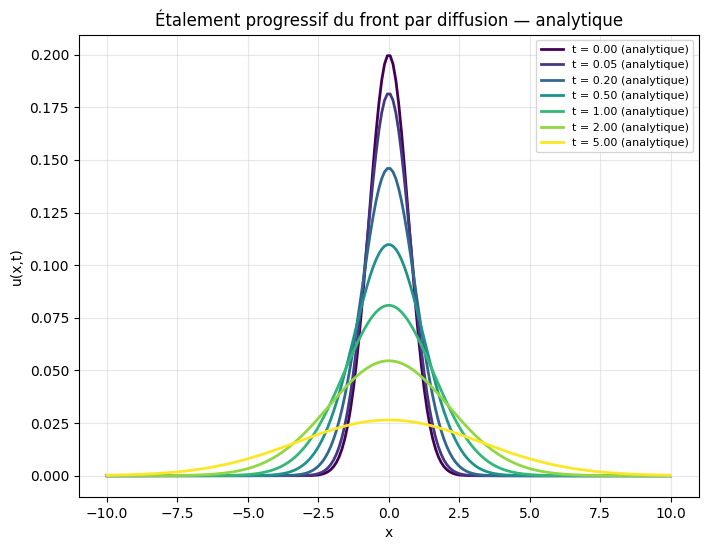

In [3]:

def u_analytique (x , t , A =0.2 , x0 =0.0 , sigma =1.0 , D =1.0 , alpha =0.1) :

# Solution analytique avec condition initiale gaussienne . 

  denom = np.sqrt (1 + (4* D * t / sigma **2))
  exp_part = np . exp ( -( x - x0 ) **2 / ( sigma **2 + 4* D * t ) )
  return A / denom * exp_part * np . exp ( - alpha * t )

# --- Évaluation de la solution analytique sur une grille (x, t) -----------

Nt = 100
x_Analytique = np . linspace ( -L , L , Nx )
t = np . linspace (0 , T , Nt )

U = np.zeros (( Nt , Nx ) )
# Précalcul de toute la matrice U (comme avant, mais sans plt dans la boucle)
for i, ti in enumerate(t):
    U[i, :] = u_analytique(x_Analytique, ti, A, x0, sigma, D, alpha)

# --- Visualisation : étalement du choc à différents instants --------------

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Résolution numérique par Volumes Finis

On discrétise le domaine en `Nx` cellules de taille dx et on intègre l'EDP sur
chaque volume de contrôle (cf. section 4 du sujet). Les flux diffusifs sont
approchés par différences finies, ce qui conduit au schéma explicite

u_i^{n+1} = u_i^n + r (u_{i+1}^n − 2u_i^n + u_{i-1}^n) − α Δt u_i^n,  avec r = DΔt/Δx²

Le pas de temps dt est fixé via le nombre de Courant `clf` pour respecter la
condition de stabilité r ≤ 1/2 (section 5 du sujet). Les bords du domaine sont
imposés à partir de la solution analytique (condition aux limites de type Dirichlet).

espace de temps 0.004500000000000001 espace de position 0.1


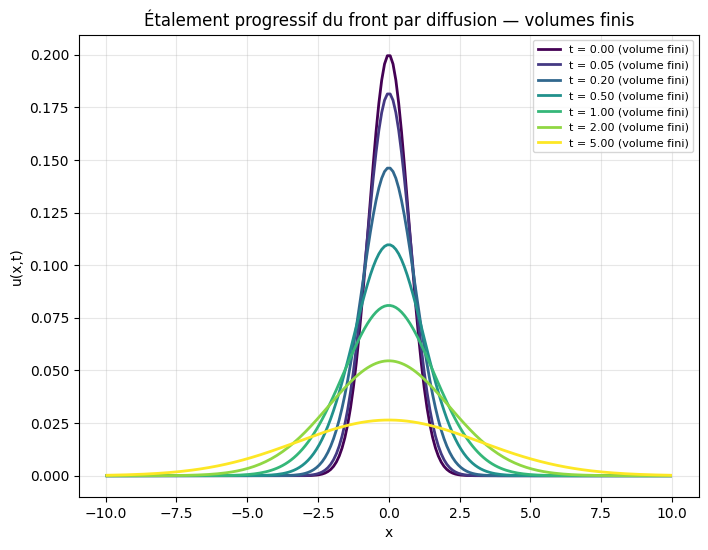

In [4]:

def u_volume_finie(A =0.2 , x0 =0.0 , sigma =1.0 , D =1.0 , alpha =0.1 , L=L, T=T, Nx=Nx, clf=0.45):
    """
    Résout l'équation de diffusion-amortissement par volumes finis.
    Retourne x_VF, t_VF, U_num pour pouvoir tracer ou comparer le résultat.
    """

    # --- Maillage spatial : centres des cellules -------------------------

    dx = 2 * L / Nx
    x_VF = -L + (np.arange(Nx) + 0.5) * dx

    # --- Pas de temps fixé par la condition de stabilité CFL --------------
    # dt = clf * dx² / D, avec clf ≤ 0.5 pour garantir r ≤ 1/2 (schéma stable)
 
    dt = clf * dx**2 / D
    Nt = int(T / dt) + 1

    print("espace de temps", dt, "espace de position", dx)

    U_num = np.zeros((Nt, Nx))
    t_VF = np.linspace(0, T, Nt)

     # --- Condition initiale : choc gaussien centré en x0 -------------------
    U_num[0, :] = A * np.exp(-(x_VF - x0)**2 / sigma**2)

    # --- Nombre de Courant r = D*dt/dx² : pilote la stabilité du schéma ----
    r = D * dt / dx**2

    for i in range(Nt - 1):
        for j in range(1, Nx - 1):
            U_num[i+1, j] = U_num[i, j] + r * (U_num[i, j+1] - 2*U_num[i, j] + U_num[i, j-1]) - alpha * dt * U_num[i, j]
        # Conditions aux limites : on impose la solution exacte aux deux bords
        # (domaine supposé assez grand pour que u soit quasi nul en x = ±L)
        U_num[i+1, 0] = u_analytique(-L, t_VF[i+1], A, x0, sigma, D, alpha)
        U_num[i+1, -1] = u_analytique(L, t_VF[i+1], A, x0, sigma, D, alpha)

    return x_VF, t_VF, U_num

# --- Résolution avec les paramètres de référence --------------------------
x_VF, t_VF, U_num = u_volume_finie()

# --- Visualisation : solution numérique à différents instants -------------
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], linewidth=2, label=f"t = {ti:.2f} (volume fini)", color=c, )

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_VF.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Superposition des deux solutions

On superpose la solution analytique (courbes) et la solution numérique
(étoiles rouges) aux mêmes instants, afin de vérifier visuellement que le
schéma Volumes Finis reproduit correctement la solution exacte (cf. section 6
du sujet : validation numérique).

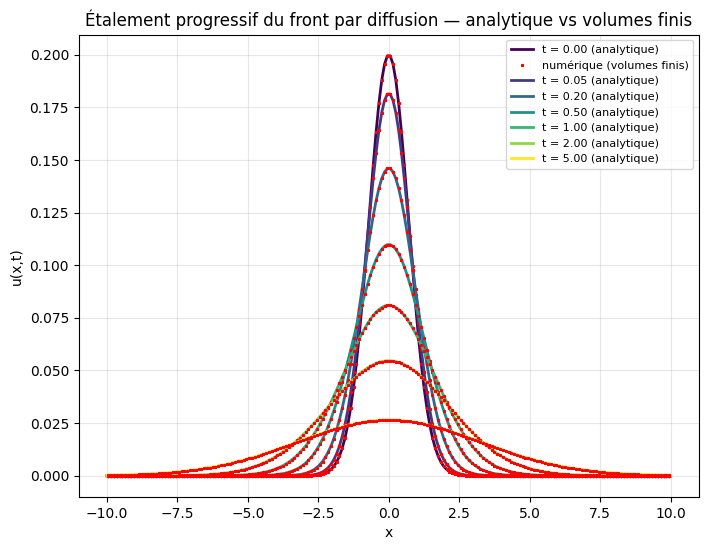

In [5]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], color="red", marker='*', markersize=2,
             linestyle='none',
            label="numérique (volumes finis)" if k == 0 else None)

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique vs volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique_vs_VF.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Quantification de l'erreur numérique

Pour valider objectivement le schéma Volumes Finis, on ne se contente pas
d'une comparaison visuelle : on calcule les erreurs L2 et L∞ entre la
solution numérique et la solution analytique, à un instant t donné
(cf. section 6 du sujet) :

L2 = √(Δx Σᵢ (u_num,i − u_exact,i)²)     
L∞ = maxᵢ |u_num,i − u_exact,i|

In [6]:
import numpy as np
dx = x_VF[1] - x_VF[0]
def erreurs_L2_Linf(x, U_num, U_exact, dx):
    """
    Calcule les erreurs L2 et L_infini entre solution numérique et exacte.
    U_num, U_exact : tableaux 1D de même taille (valeurs de u sur x)
    """
    diff = U_num - U_exact
    L2 = np.sqrt(dx * np.sum(diff**2))
    Linf = np.max(np.abs(diff))
    return L2, Linf

# ------Exemple : erreur à t = 1.0-------
ti = 1.0
idx = np.argmin(np.abs(t_VF - ti))
U_exacte = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
U_numerique = U_num[idx, :]

L2, Linf = erreurs_L2_Linf(x_VF, U_numerique, U_exacte, dx)
print(f"t = {ti:.2f}  |  L2 = {L2:.6f}  |  L∞ = {Linf:.6f}")

t = 1.00  |  L2 = 0.000094  |  L∞ = 0.000067


### 6. Évolution de l'erreur au cours de la simulation

L'erreur ponctuelle (à t = 1.0) ne suffit pas à juger de la qualité du schéma
sur toute la durée de la simulation. On calcule ici L2 et L∞ à **chaque**
instant simulé, pour voir si l'erreur reste bornée, croît, ou se stabilise
au cours du temps.

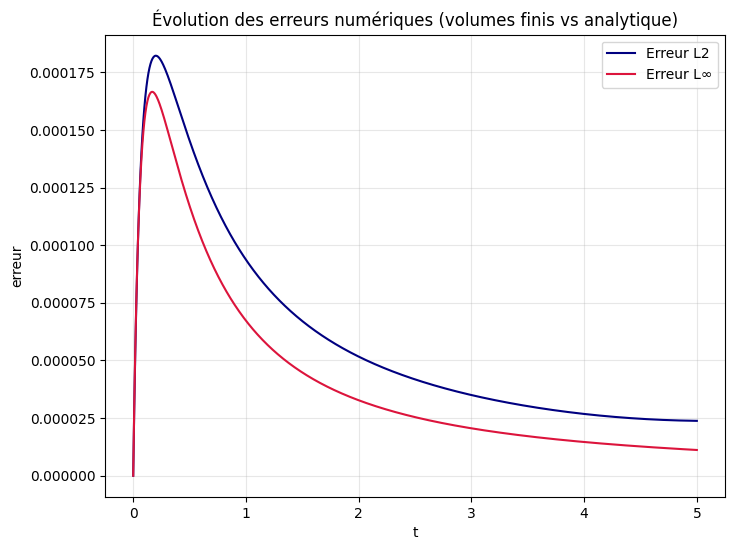

Erreur L2 max sur toute la simulation   : 0.000182
Erreur L∞ max sur toute la simulation   : 0.000167


In [7]:
L2_list = []
Linf_list = []

# --- Erreur à chaque instant simulé ----------------------------------------
for n in range(t_VF.size):
    U_exacte_n = u_analytique(x_VF, t_VF[n], A, x0, sigma, D, alpha)
    U_num_n = U_num[n, :]
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_n, U_exacte_n, dx)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)

L2_list = np.array(L2_list)
Linf_list = np.array(Linf_list)

# --- Graphe de l'évolution des erreurs ---
plt.figure(figsize=(8, 6))
plt.plot(t_VF, L2_list, label="Erreur L2", color='navy')
plt.plot(t_VF, Linf_list, label="Erreur L∞", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur')
plt.title("Évolution des erreurs numériques (volumes finis vs analytique)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('erreurs_numeriques.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Erreur L2 max sur toute la simulation   : {L2_list.max():.6f}")
print(f"Erreur L∞ max sur toute la simulation   : {Linf_list.max():.6f}")

### 7. Étude de convergence : raffinement du maillage

On vérifie ici que le schéma Volumes Finis converge bien vers la solution
exacte lorsque le maillage est raffiné (Nx croissant, donc dx décroissant),
et on estime son **ordre de convergence** (cf. section 6 du sujet).

Un schéma d'ordre p vérifie erreur ≈ C · dx^p, donc en échelle log-log :
ln(erreur) ≈ p · ln(dx) + cste — la pente de la droite donne l'ordre p.

In [65]:
Nx_list = [200, 400, 800, 1600, 3200] # maillages de plus en plus fins

L1_list = []
L2_list = []
Linf_list = []
dx_list = []

for i in Nx_list:
    x_VF, t_VF, U_num = u_volume_finie(Nx=i)
    dx = x_VF[1] - x_VF[0]
    idx = np.argmin(np.abs(t_VF - 3)) # on compare toujours au même instant t=3

    U_exacte_3 = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
    U_num_3 = U_num[idx, :]
    diff = U_num_3 - U_exacte_3
    L1_n = dx * np.sum(np.abs(diff)) # erreur L1 (norme absolue intégrée)
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_3, U_exacte_3, dx)
    L1_list.append(L1_n)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)
    dx_list.append(dx)

    print(f"Nx={i:5d}  |  dx={dx:.6f}  |  t_VF[idx]={t_VF[idx]:.4f}  |  "
          f"L2={L2_n:.3e}  |  Linf={Linf_n:.3e}")

# --- Récapitulatif des erreurs pour chaque maillage -------------------------
df_convergence = pd.DataFrame({
    'Nx': Nx_list,
    'dx': dx_list,
    'L1': L1_list,
    'L2': L2_list,
    'Linf': Linf_list
})

print(df_convergence)

df_convergence.to_csv('convergence_maillage.csv', index=False)


espace de temps 0.004500000000000001 espace de position 0.1
Nx=  200  |  dx=0.100000  |  t_VF[idx]=3.0018  |  L2=3.498e-05  |  Linf=2.055e-05
espace de temps 0.0011250000000000003 espace de position 0.05
Nx=  400  |  dx=0.050000  |  t_VF[idx]=2.9995  |  L2=5.790e-06  |  Linf=2.799e-06
espace de temps 0.0002812500000000001 espace de position 0.025
Nx=  800  |  dx=0.025000  |  t_VF[idx]=2.9999  |  L2=1.245e-06  |  Linf=5.647e-07
espace de temps 7.031250000000002e-05 espace de position 0.0125
Nx= 1600  |  dx=0.012500  |  t_VF[idx]=3.0000  |  L2=5.678e-07  |  Linf=3.216e-07
espace de temps 1.7578125000000005e-05 espace de position 0.00625
Nx= 3200  |  dx=0.006250  |  t_VF[idx]=3.0000  |  L2=1.178e-07  |  Linf=9.035e-08
     Nx       dx            L1            L2          Linf
0   200  0.10000  1.085613e-04  3.497861e-05  2.055416e-05
1   400  0.05000  1.996844e-05  5.790289e-06  2.798558e-06
2   800  0.02500  4.399160e-06  1.244723e-06  5.647102e-07
3  1600  0.01250  1.900257e-06  5.67820

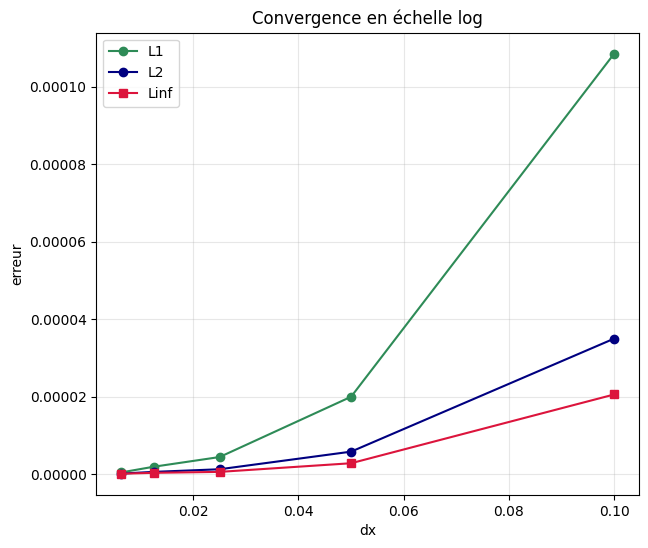

In [66]:
# --- Visualisation de la décroissance de l'erreur avec dx (échelle log-log) -
plt.figure(figsize=(7, 6))
plt.plot(dx_list, L1_list, 'o-', label="L1", color='seagreen')
plt.plot(dx_list, L2_list, 'o-', label="L2", color='navy')
plt.plot(dx_list, Linf_list, 's-', label="Linf", color='crimson')
plt.xlabel('dx')
plt.ylabel('erreur')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_loglog.png', dpi=300, bbox_inches='tight')
plt.show()

Ordre de convergence estimé (L1)   : 1.95
Ordre de convergence estimé (L2)   : 1.98
Ordre de convergence estimé (Linf) : 1.88


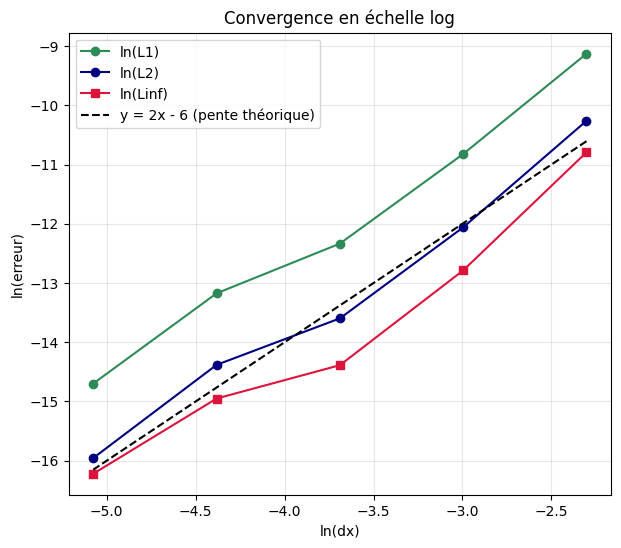

In [67]:
# --- Estimation de l'ordre de convergence par régression linéaire ----------
# En échelle log-log, la pente de ln(erreur) en fonction de ln(dx) donne
# directement l'ordre p du schéma (erreur ~ dx^p).
ln_dx = np.log(dx_list)
ln_L1 = np.log(L1_list)
ln_L2 = np.log(L2_list)
ln_Linf = np.log(Linf_list)

# Estimation de la pente (= ordre de convergence) par régression linéaire
pente_L2 = np.polyfit(ln_dx, ln_L2, 1)[0]
pente_Linf = np.polyfit(ln_dx, ln_Linf, 1)[0]
pente_L1 = np.polyfit(ln_dx, ln_L1, 1)[0]
print(f"Ordre de convergence estimé (L1)   : {pente_L1:.2f}")
print(f"Ordre de convergence estimé (L2)   : {pente_L2:.2f}")
print(f"Ordre de convergence estimé (Linf) : {pente_Linf:.2f}")

# Pente théorique attendue pour un schéma d'ordre 2 (référence visuelle)
y_theorique = 2 * ln_dx - 6

plt.figure(figsize=(7, 6))
plt.plot(ln_dx, ln_L1, 'o-', label="ln(L1)", color='seagreen')
plt.plot(ln_dx, ln_L2, 'o-', label="ln(L2)", color='navy')
plt.plot(ln_dx, ln_Linf, 's-', label="ln(Linf)", color='crimson')
plt.plot(ln_dx, y_theorique, 'k--', label="y = 2x - 6 (pente théorique)")
plt.xlabel('ln(dx)')
plt.ylabel('ln(erreur)')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_log.png', dpi=300, bbox_inches='tight')
plt.show()

### 8. Étude de sensibilité : différents scénarios physiques

Pour mieux comprendre le rôle de chaque paramètre du modèle, on simule
plusieurs scénarios en faisant varier D (diffusion), α (amortissement),
σ (largeur initiale du choc) et le nombre de Courant `clf`. On inclut
notamment un scénario **instable** (CFL > 0.5) pour illustrer concrètement
la condition de stabilité.

In [9]:
scenarios = {
    "Diffusion pure (alpha=0)":       dict(D=1.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance dominante":         dict(D=0.2, alpha=1.0,  sigma=1.0, clf=0.45),
    "Diffusion rapide":               dict(D=5.0, alpha=0.1,  sigma=1.0, clf=0.45),
    "Front raide":                    dict(D=1.0, alpha=0.1,  sigma=0.3, clf=0.45),
    "Front large":                    dict(D=1.0, alpha=0.1,  sigma=3.0, clf=0.45),
    "Diffusion lente":                dict(D=0.05, alpha=0.1, sigma=1.0, clf=0.45),
    "Décroissance nulle + rapide":    dict(D=5.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance forte + lente":     dict(D=0.05, alpha=1.0, sigma=1.0, clf=0.45),
    "CFL limite (0.5)":               dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.5),
    "Instable (CFL > 0.5)":           dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.6),
}

resultats = {}

for nom, p in scenarios.items():
    D, alpha, sigma, clf = p["D"], p["alpha"], p["sigma"], p["clf"]

    # On appelle directement la fonction Volumes Finis : A, x0, L, T, Nx
    # restent ceux du scénario de référence, seuls D, alpha, sigma, clf varient.
    x_VF, t, U = u_volume_finie(A=A, x0=x0, sigma=sigma, D=D, alpha=alpha,
                                 L=L, T=T, Nx=Nx, clf=clf)

    # dx, dt, r sont recalculés à partir du résultat pour être sûrs qu'ils
    # correspondent exactement à cet appel (et non à une variable globale périmée).
    dx = x_VF[1] - x_VF[0]
    dt = t[1] - t[0]
    r = D * dt / dx**2

    # Solution exacte avec les MÊMES D, alpha, sigma que le scénario
    U_exacte = np.zeros_like(U)
    for i, ti in enumerate(t):
        U_exacte[i, :] = u_analytique(x_VF, ti, A=A, x0=x0, sigma=sigma, D=D, alpha=alpha)

    resultats[nom] = dict(x=x_VF.copy(), t=t.copy(), U=U.copy(), U_exacte=U_exacte,
                           dx=dx, D=D, alpha=alpha, sigma=sigma, clf=clf, dt=dt, r=r)

espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.022500000000000006 espace de position 0.1
espace de temps 0.0009000000000000003 espace de position 0.1
espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.09000000000000002 espace de position 0.1
espace de temps 0.0009000000000000003 espace de position 0.1
espace de temps 0.09000000000000002 espace de position 0.1
espace de temps 0.005000000000000001 espace de position 0.1
espace de temps 0.006000000000000001 espace de position 0.1


## Comparaison analytique vs volumes finis de tous les scénarios

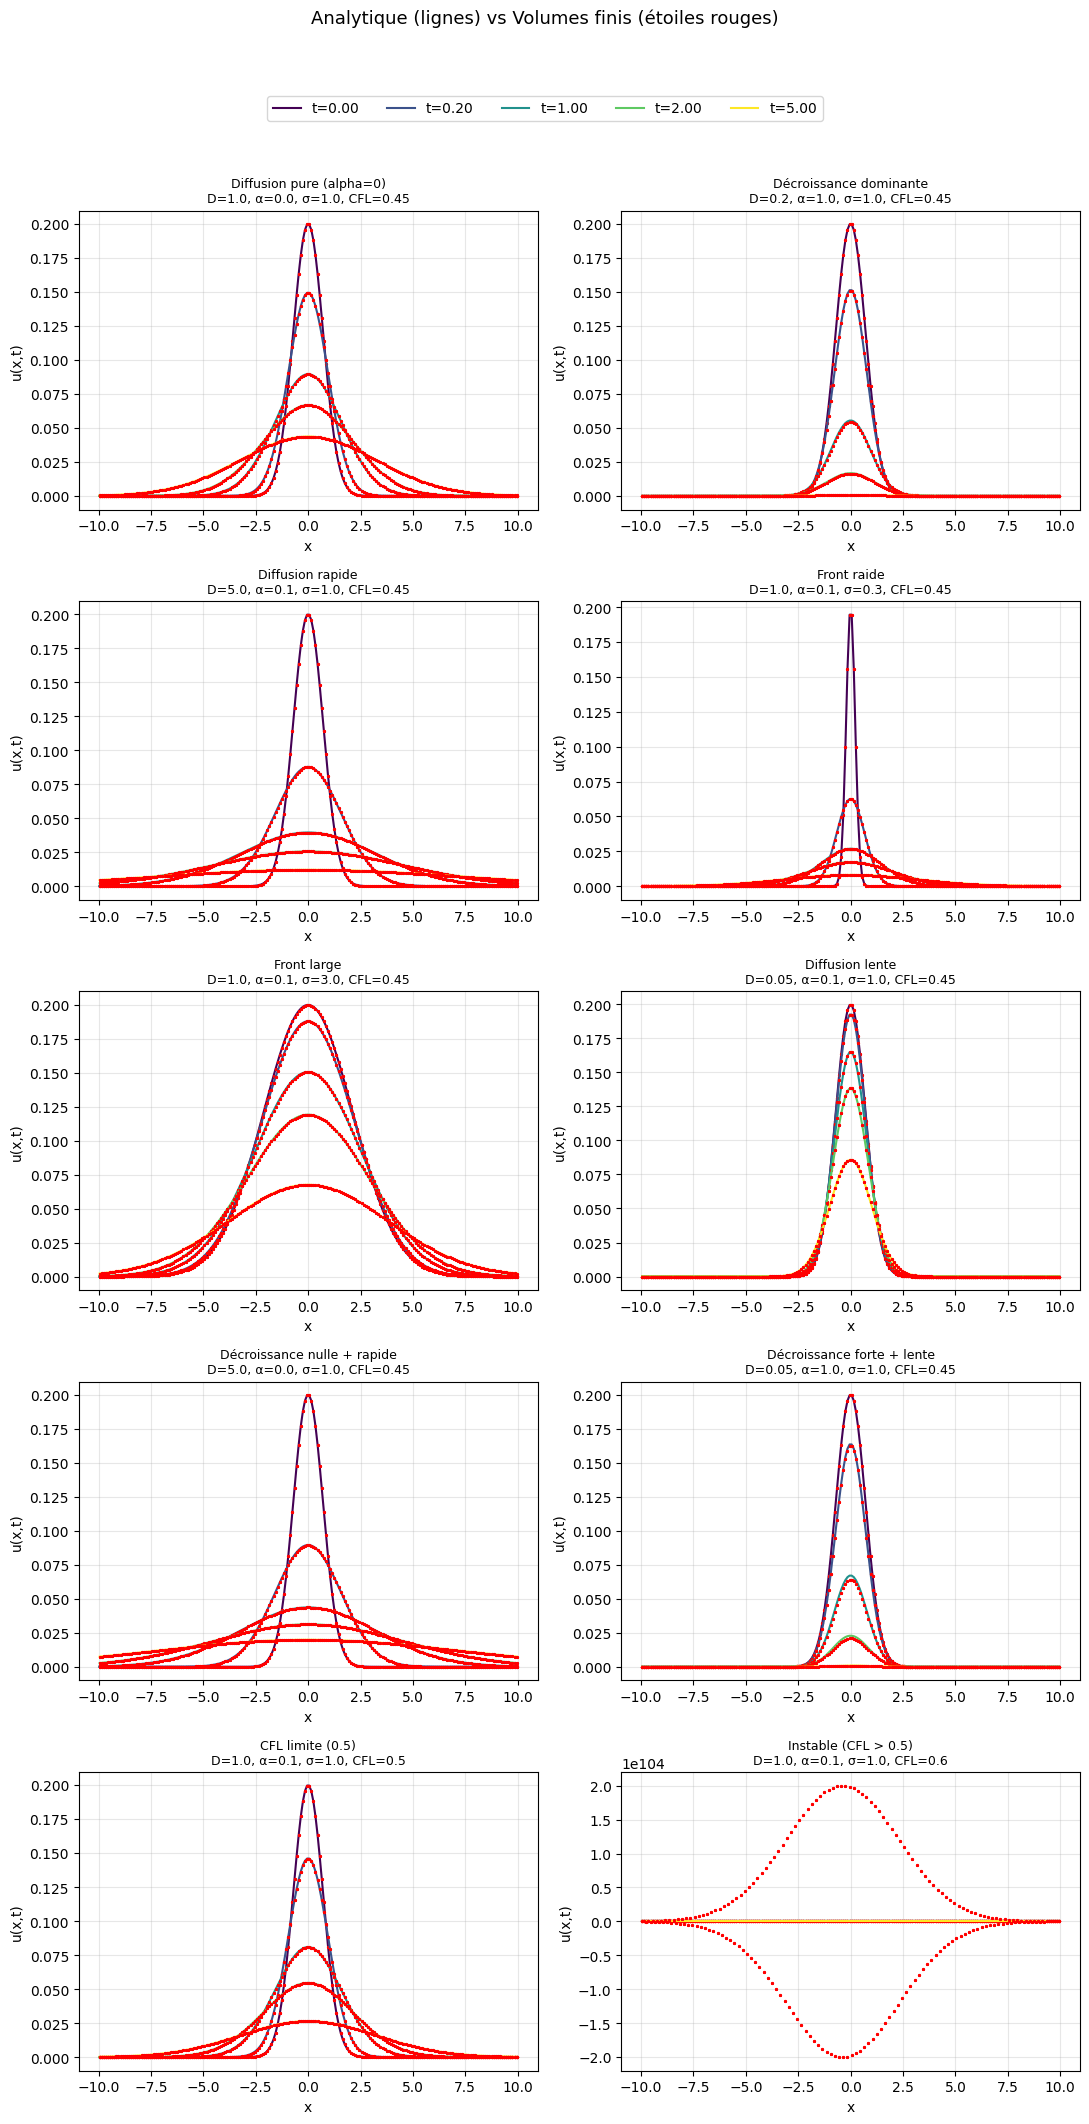

In [10]:
import math

noms = list(resultats.keys())
n_scen = len(noms)
ncols = 2
nrows = math.ceil(n_scen / ncols) # grille de sous-graphes, 2 colonnes

plt.style.use('default')
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))


for k, nom in enumerate(noms):
    ax = axes[k]
    res = resultats[nom]
    x_r, t_r, U_r = res["x"], res["t"], res["U"]
    D_r, alpha_r, sigma_r = res["D"], res["alpha"], res["sigma"]

    for ti, c in zip(temps_a_tracer, colors):
        idx = np.argmin(np.abs(t_r - ti)) 
        U_exacte = res["U_exacte"] 
        ax.plot(x_r, U_exacte[idx], color=c, linewidth=1.5, label=f"t={ti:.2f}")
        ax.plot(x_r, U_r[idx, :], color="red", marker='*', markersize=2,
                linestyle='none')

    ax.set_title(f"{nom}\nD={D_r}, α={alpha_r}, σ={sigma_r}, CFL={res['clf']}", fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.grid(True, alpha=0.3)

# On masque les sous-graphes inutilisés si le nombre de scénarios est impair
for k in range(n_scen, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(temps_a_tracer), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Analytique (lignes) vs Volumes finis (étoiles rouges)", y=1.06, fontsize=13)
plt.tight_layout()
plt.savefig('diffusion_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()


## Tableau récapitulatif de tous les scénarios

In [ ]:
# --- Résumé des paramètres physiques et numériques de chaque scénario -----
print(f"{'Scénario':30s} {'D':>6s} {'alpha':>7s} {'sigma':>7s} {'CFL':>6s} {'Nt':>7s} ")
print("-" * 100)
for nom in noms:
    res = resultats[nom]
    
    print(f"{nom:30s} {res['D']:6.2f} {res['alpha']:7.2f} {res['sigma']:7.2f} "
          f"{res['clf']:6.2f} {len(res['t']):7d} ")


Scénario                            D   alpha   sigma    CFL      Nt 
----------------------------------------------------------------------------------------------------
Diffusion pure (alpha=0)         1.00    0.00    1.00   0.45    1112 
Décroissance dominante           0.20    1.00    1.00   0.45     223 
Diffusion rapide                 5.00    0.10    1.00   0.45    5556 
Front raide                      1.00    0.10    0.30   0.45    1112 
Front large                      1.00    0.10    3.00   0.45    1112 
Diffusion lente                  0.05    0.10    1.00   0.45      56 
Décroissance nulle + rapide      5.00    0.00    1.00   0.45    5556 
Décroissance forte + lente       0.05    1.00    1.00   0.45      56 
CFL limite (0.5)                 1.00    0.10    1.00   0.50    1000 
Instable (CFL > 0.5)             1.00    0.10    1.00   0.60     834 


# Partie Deep Learning

Après avoir validé le modèle physique par Volumes Finis, on passe à
l'approche par apprentissage automatique:
un réseau de neurones classique (MLP) sera d'abord entraîné à reproduire
la solution analytique, avant d'introduire un PINN qui intègre directement
l'EDP dans sa fonction de coût.

## 11. Génération du jeu de données

Le MLP est entraîné en mode supervisé classique : on génère des couples
(x, t) → u(x, t) à partir de la solution analytique. Un sur-échantillonnage
est appliqué près du choc initial (x proche de x0, t proche de 0), car c'est
la zone où u varie le plus brutalement et où le réseau doit être le plus précis.

In [11]:
# Paramètres du choc — remise à zéro après la boucle sur les scénarios,
# qui a réassigné A, x0, sigma, D, alpha, clf en variables globales.
A = 0.2
x0 = 0.0
sigma = 1.0
D = 1.0
alpha = 0.1
L = 10
T = 5
print(D, alpha, sigma,A, x0, Nt,T)

1.0 0.1 1.0 0.2 0.0 100 5


In [12]:
# Génération d'un jeu de données avec sur-échantillonnage renforcé
# autour du choc initial (t proche de 0, x proche de x0)

np.random.seed(0) # reproductibilité

N_total = 7000
N_focus = int(0.3 * N_total)      # 30% des points concentrés près du choc initial
N_uniform = N_total - N_focus

# Partie 1 : échantillonnage uniforme sur tout le domaine (x, t)(identique à avant)
t_unif = np.random.uniform(0, T, N_uniform)
x_unif = np.random.uniform(-L, L, N_uniform)

# Partie 2 : échantillonnage concentré près de (x0, t=0), là où u varie vite
# (loi exponentielle en t pour privilégier les temps courts, loi normale en x
#  centrée sur x0 avec l'écart-type du choc initial sigma)
t_focus = np.clip(np.random.exponential(scale=0.3, size=N_focus), 0, T)
x_focus = np.clip(np.random.normal(loc=x0, scale=sigma, size=N_focus), -L, L)

t_data2 = np.concatenate([t_unif, t_focus])
x_data2 = np.concatenate([x_unif, x_focus])
u_data2 = u_analytique(x_data2, t_data2, A, x0, sigma, D, alpha)

df = pd.DataFrame({'t': t_data2, 'x': x_data2, 'u_exacte': u_data2})
df.to_csv('dataset_diffusion.csv', index=False)

print(f"Total points : {len(df)}  (dont {N_focus} concentrés près du choc initial)")

Total points : 7000  (dont 2100 concentrés près du choc initial)


In [13]:
# --- Aperçu rapide du jeu de données ---------------------------------------

print("les lignes du DataFrame :")
print(df.head())
print("Résumé statistique du DataFrame :")
df.describe()

les lignes du DataFrame :
          t         x  u_exacte
0  2.744068  5.179377  0.004676
1  3.575947  6.348490  0.002568
2  3.013817 -4.355971  0.009573
3  2.724416 -4.896879  0.005884
4  2.118274 -1.172848  0.045470
Résumé statistique du DataFrame :


,t,x,u_exacte
count,7000.000000,7000.000000,7.000000e+03
mean,1.830358,-0.076787,3.919684e-02
std,1.580687,4.878460,4.925343e-02
min,0.000062,-9.996992,6.031054e-41
25%,0.332043,-2.815086,6.930451e-04
50%,1.448988,-0.044515,1.719647e-02
75%,3.180146,2.732844,6.385298e-02
max,4.999820,9.999559,1.978473e-01


### Visualisation des données

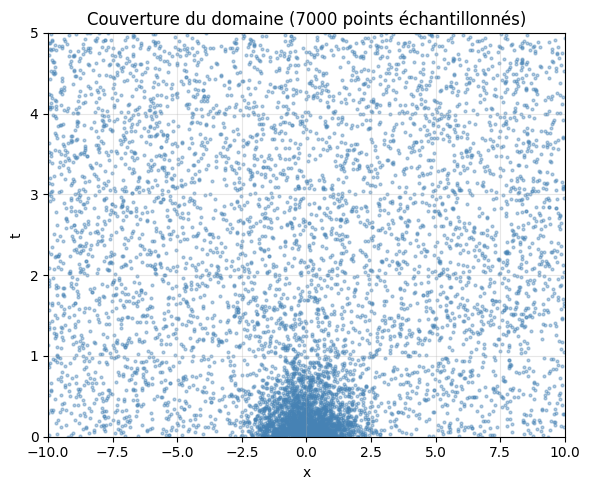

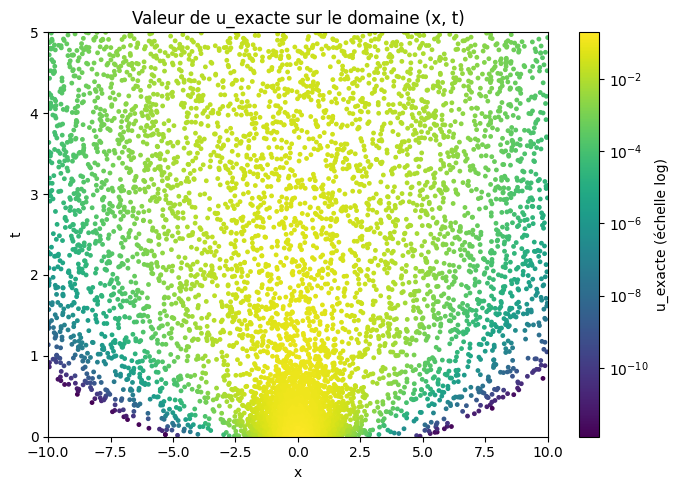

In [14]:
# ---------------------------------------------------------------------
# Graphe 1 : couverture du domaine (x, t)
# On vérifie visuellement que le sur-échantillonnage près de (x0, t=0)
# est bien visible (points plus denses dans cette zone).
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['x'], df['t'], s=4, alpha=0.4, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(f"Couverture du domaine ({len(df)} points échantillonnés)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('couverture_domaine.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------
# Graphe 2 : valeur de u_exacte sur le domaine (échelle log)
# u varie sur plusieurs ordres de grandeur entre le centre du choc et
# les zones lointaines/tardives, d'où l'usage d'une échelle logarithmique.
# ---------------------------------------------------------------------
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 5))

# LogNorm exige des valeurs strictement positives : on écarte les valeurs
# numériquement nulles (en dessous d'un seuil) qui feraient planter LogNorm
mask = df['u_exacte'] > 1e-12

sc = ax.scatter(df['x'][mask], df['t'][mask], c=df['u_exacte'][mask], s=6,
                 cmap='viridis',
                 norm=LogNorm(vmin=df['u_exacte'][mask].min(),
                               vmax=df['u_exacte'][mask].max()))
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('u_exacte (échelle log)')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title("Valeur de u_exacte sur le domaine (x, t)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
plt.tight_layout()
plt.savefig('valeur_u_exacte.png', dpi=300, bbox_inches='tight')
plt.show()

### Répartition des données

In [15]:

df = pd.read_csv('dataset_diffusion.csv')
# Étape 1 : séparer train (70%) et "temp" (30%)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42)

# Étape 2 : séparer temp en validation (15%) et test (15%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Train : {len(df_train)} points")
print(f"Val   : {len(df_val)} points")
print(f"Test  : {len(df_test)} points")

Train : 4900 points
Val   : 1050 points
Test  : 1050 points


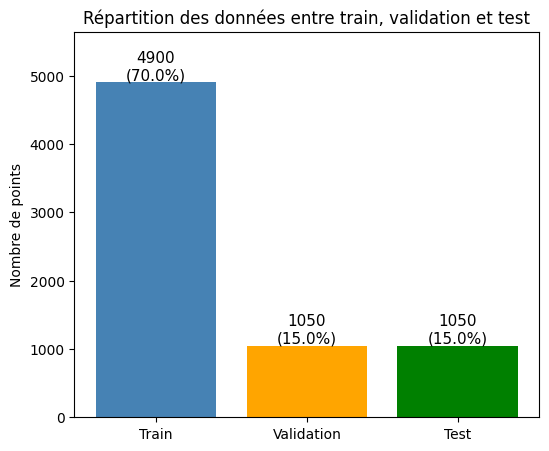

In [16]:
# --- Visualisation de la répartition des données ---------------------------
labels = ['Train', 'Validation', 'Test']
counts = [len(df_train), len(df_val), len(df_test)]
total = sum(counts)

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts, color=['steelblue', 'orange', 'green'])

for bar, count in zip(bars, counts):
    pourcentage = 100 * count / total
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{count}\n({pourcentage:.1f}%)",
              ha='center', va='bottom', fontsize=11)

plt.ylabel('Nombre de points')
plt.title("Répartition des données entre train, validation et test")
plt.ylim(0, max(counts) * 1.15)  # un peu de marge en haut pour le texte
plt.savefig('repartition_donnees.png', dpi=300, bbox_inches='tight')
plt.show()

### 14. Normalisation des données

Le réseau de neurones s'entraîne mieux quand ses entrées et sorties sont
d'ordre de grandeur comparable. On applique donc :
- une **normalisation standard** (centrer-réduire) sur x et t ;
- un **passage au log** sur u avant normalisation, car u varie sur plusieurs
  ordres de grandeur entre le centre du choc et les zones lointaines/tardives
  (cf. visualisation en échelle log de la section précédente).

Les moyennes/écarts-types sont calculés **uniquement sur le train**, puis
réutilisés tels quels pour val et test, afin d'éviter toute fuite d'information.

In [17]:
eps = 1e-12  # évite log(0) pour les valeurs de u numériquement nulles

# --- Passage au log de u avant normalisation --------------------------------

u_log_train = np.log(df_train['u_exacte'].values + eps)
u_log_val   = np.log(df_val['u_exacte'].values + eps)
u_log_test  = np.log(df_test['u_exacte'].values + eps)

# --- Statistiques de normalisation calculées UNIQUEMENT sur le train --------
x_mean, x_std = df_train['x'].mean(), df_train['x'].std()
t_mean, t_std = df_train['t'].mean(), df_train['t'].std()
u_mean, u_std = u_log_train.mean(), u_log_train.std()

def normalize(df_subset, u_log):
    """
    Centre-réduit x et t, et centre-réduit log(u), en utilisant toujours
    les statistiques (mean, std) calculées sur le train.
    """
    x_norm = (df_subset['x'].values - x_mean) / x_std
    t_norm = (df_subset['t'].values - t_mean) / t_std
    u_norm = (u_log - u_mean) / u_std
    X = torch.tensor(np.column_stack([x_norm, t_norm]), dtype=torch.float32)
    y = torch.tensor(u_norm, dtype=torch.float32).view(-1, 1)
    return X, y

X_train, y_train = normalize(df_train, u_log_train)
X_val,   y_val   = normalize(df_val,   u_log_val)
X_test,  y_test  = normalize(df_test,  u_log_test)


In [18]:
# --- Vérification : après normalisation, X_train doit être ~ N(0, 1) -------
print(X_train.shape, y_train.shape)
print(X_train.mean(dim=0), X_train.std(dim=0))

torch.Size([4900, 2]) torch.Size([4900, 1])
tensor([ 3.8925e-10, -5.8388e-10]) tensor([1., 1.])


### 15. Comparaison rapide d'architectures

Avant de choisir l'architecture définitive du MLP, on compare rapidement
plusieurs configurations (profondeur, largeur, fonction d'activation) sur
un entraînement court (400 époques), afin d'identifier un bon compromis
entre capacité du modèle et erreur de validation.

In [19]:
def make_mlp(n_layers, hidden, act_fn):
    """Construit un MLP simple : n_layers couches cachées de taille `hidden`,
    suivies d'une couche de sortie linéaire (1 neurone, pas d'activation)."""
    layers = [nn.Linear(2, hidden), act_fn()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden, hidden), act_fn()]
    layers += [nn.Linear(hidden, 1)]
    return nn.Sequential(*layers)

def count_params(m):
    """Nombre total de paramètres entraînables du modèle."""
    return sum(p.numel() for p in m.parameters())

def train_quick(model, epochs=400, lr=1e-3):
    """
    Entraînement court (pas de mini-batchs : tout le train à chaque époque)
    utilisé uniquement pour comparer rapidement des architectures entre elles,
    pas pour l'entraînement final.
    """

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    best_val = float('inf')
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = crit(model(X_train), y_train)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_val), y_val).item()
        if vl < best_val:
            best_val = vl
    return best_val, loss.item()

# --- Grille de configurations à comparer -----------------------------------
configs = [
    ("1x16, tanh", 1, 16, nn.Tanh),
    ("1x32, tanh", 1, 32, nn.Tanh),
    ("2x32, tanh", 2, 32, nn.Tanh),
    ("3x32, tanh", 3, 32, nn.Tanh),
    ("4x32, tanh", 4, 32, nn.Tanh),
    ("3x64, tanh", 3, 64, nn.Tanh),
    ("3x32, relu", 3, 32, nn.ReLU),
]

resultats_archi = []
print(f"{'config':15s} {'#params':>8s} {'train_mse':>12s} {'val_mse':>12s}")
for name, nl, h, act in configs:
    torch.manual_seed(0)
    m = make_mlp(nl, h, act)
    n_params = count_params(m)
    val_mse, train_mse = train_quick(m, epochs=400)
    resultats_archi.append((name, n_params, train_mse, val_mse))
    print(f"{name:15s} {n_params:8d} {train_mse:12.6f} {val_mse:12.6f}")

df_archi = pd.DataFrame(resultats_archi, columns=['config', 'n_params', 'train_mse', 'val_mse'])
df_archi.to_csv('comparaison_architectures.csv', index=False)

config           #params    train_mse      val_mse
1x16, tanh            65     0.246751     0.201504
1x32, tanh           129     0.173149     0.139552
2x32, tanh          1185     0.023519     0.016696
3x32, tanh          2241     0.012766     0.008346
4x32, tanh          3297     0.009524     0.006089
3x64, tanh          8577     0.009715     0.006422
3x32, relu          2241     0.007565     0.005171


### 16. Architecture retenue pour le MLP

Suite à la comparaison précédente, on retient une architecture à 3 couches
cachées de 32 neurones avec activation `tanh` : un bon compromis entre
capacité de représentation et risque de sur-apprentissage sur ce problème.

In [20]:


class MLP(nn.Module):
    """
    MLP classique : 2 entrées (x, t) -> 1 sortie (u prédit).
    3 couches cachées de 32 neurones, activation tanh (dérivable partout,
    utile même si ce MLP n'a pas besoin de dérivées — cohérence avec le PINN
    qui suivra et qui, lui, en a besoin).
    """
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# --- Modèle ET optimiseur créés ensemble, dans la même cellule -------------
# (évite un bug classique : optimiseur pointant vers un ancien modèle)
torch.manual_seed(0) 
model = MLP(hidden_dim=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Vérification de synchronisation modèle / optimiseur -------------------
model_param_ids = set(id(p) for p in model.parameters())
optim_param_ids = set(id(p) for group in optimizer.param_groups for p in group['params'])
print("Modèle et optimiseur synchronisés :", model_param_ids == optim_param_ids)

Modèle et optimiseur synchronisés : True


### Entrainement de modèle

In [21]:
n_epochs = 1790
train_losses, val_losses = [], []
best_val_loss = float('inf') # on garde les poids du meilleur modèle (early-stopping "manuel")
best_model_state = None

for epoch in range(n_epochs):
    # --- Phase d'entraînement ------------------------------------------
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    # --- Phase de validation ---------------------------------------------
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # On sauvegarde les poids si la loss de validation s'améliore
    # (protège contre le sur-apprentissage sur les dernières époques)
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Train loss: {loss.item():.6f} | Val loss: {val_loss.item():.6f}")

# --- On restaure les poids du meilleur modèle rencontré ---------------------
model.load_state_dict(best_model_state)
print(f"Meilleure val loss : {best_val_loss:.6f}")

Epoch    0 | Train loss: 1.025500 | Val loss: 0.912405
Epoch  200 | Train loss: 0.044934 | Val loss: 0.034432
Epoch  400 | Train loss: 0.012739 | Val loss: 0.008332
Epoch  600 | Train loss: 0.009500 | Val loss: 0.006380
Epoch  800 | Train loss: 0.007350 | Val loss: 0.004977
Epoch 1000 | Train loss: 0.005530 | Val loss: 0.003806
Epoch 1200 | Train loss: 0.003915 | Val loss: 0.002777
Epoch 1400 | Train loss: 0.002801 | Val loss: 0.002143
Epoch 1600 | Train loss: 0.001675 | Val loss: 0.001298
Meilleure val loss : 0.000865


### Courbe d'apprentissage

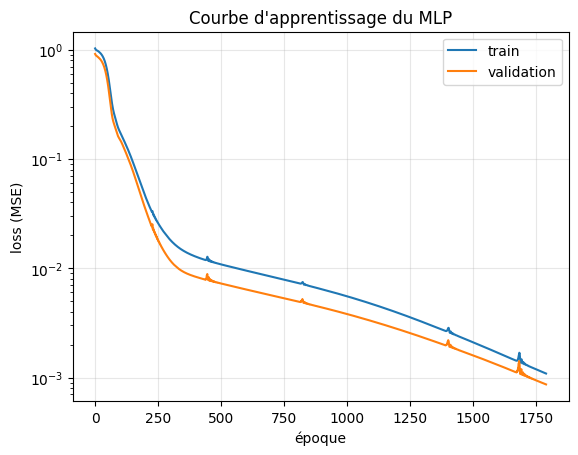

In [22]:
# --- Courbe d'apprentissage : suivi du sur/sous-apprentissage --------------
# Échelle log car la loss décroît sur plusieurs ordres de grandeur.
# Si val_losses remonte alors que train_losses continue de baisser,
# c'est un signe de sur-apprentissage.
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.yscale('log')
plt.xlabel('époque')
plt.ylabel('loss (MSE)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Courbe d'apprentissage du MLP")
plt.savefig('courbe_apprentissage_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

### Évaluation du MLP sur le jeu de test

On évalue le MLP sur les données de test (jamais vues pendant
l'entraînement), après avoir inversé la transformation log + normalisation
appliquée en amont, pour comparer u_prédit et u_exact dans l'échelle physique
d'origine (et non dans l'espace normalisé/log utilisé pour l'entraînement).

In [23]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy().flatten()

# --- Dénormalisation : inverse exact de la transformation d'entraînement ---
# (norm -> log -> échelle physique)
u_log_pred = y_pred_norm * u_std + u_mean
u_pred = np.exp(u_log_pred) - eps
u_exacte_test = np.exp(u_log_test) - eps

diff = u_pred - u_exacte_test
MSE_mlp  = np.mean(diff**2)
L2_mlp   = np.sqrt(MSE_mlp)          # RMSE
MAE_mlp  = np.mean(np.abs(diff))
Linf_mlp = np.max(np.abs(diff))

print(f"Erreur MLP (test) | MSE={MSE_mlp:.3e} | L2(RMSE)={L2_mlp:.3e} | MAE={MAE_mlp:.3e} | L∞={Linf_mlp:.3e}")

Erreur MLP (test) | MSE=7.049e-06 | L2(RMSE)=2.655e-03 | MAE=1.240e-03 | L∞=2.219e-02


### Sauvegarde du modèle entraîné

On sauvegarde à la fois les poids du MLP et les paramètres de normalisation
(x_mean, x_std, t_mean, t_std, u_mean, u_std), indispensables pour réutiliser
le modèle plus tard sans avoir à ré-entraîner ou à recalculer ces statistiques.

In [24]:
# --- Sauvegarde du MLP entraîné + paramètres de normalisation ---
torch.save({
    'model_state_dict': model.state_dict(),
    'hidden_dim': 32,
    'x_mean': x_mean, 'x_std': x_std,
    't_mean': t_mean, 't_std': t_std,
    'u_mean': u_mean, 'u_std': u_std,
    'eps': eps,
}, 'mlp_reference.pth')

print("MLP sauvegardé dans mlp_reference.pth")

MLP sauvegardé dans mlp_reference.pth


### 17. Comparaison finale : Analytique vs Volumes Finis vs MLP

On évalue maintenant le MLP entraîné sur une grille régulière (x, t) qui
couvre tout le domaine de simulation, et on superpose les trois solutions :
- la solution **analytique** (référence exacte) ;
- la solution **Volumes Finis** (référence numérique validée en partie 1) ;
- la solution **MLP** (le réseau entraîné en supervisé).

On calcule ensuite l'erreur L2 de chaque méthode numérique par rapport à
l'analytique, à chaque instant t, pour voir si l'erreur du MLP reste
comparable à celle des Volumes Finis ou si elle se dégrade (notamment loin
des zones sur-échantillonnées lors de la génération du jeu de données).

espace de temps 0.004500000000000001 espace de position 0.1


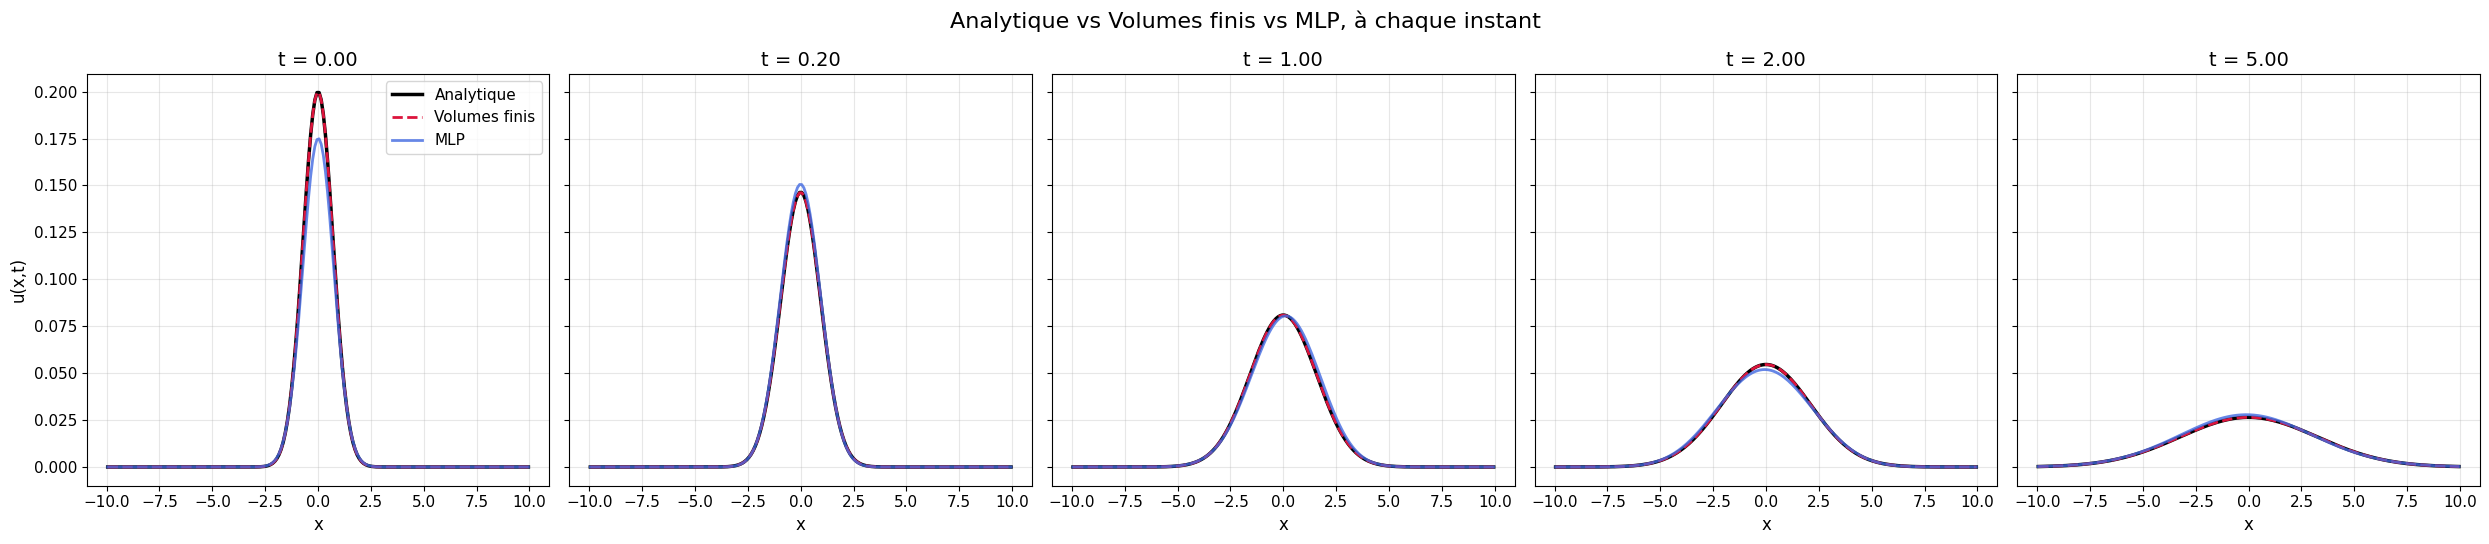

Erreur L2 max — Volumes finis : 0.000182
Erreur L2 max — MLP           : 0.025164


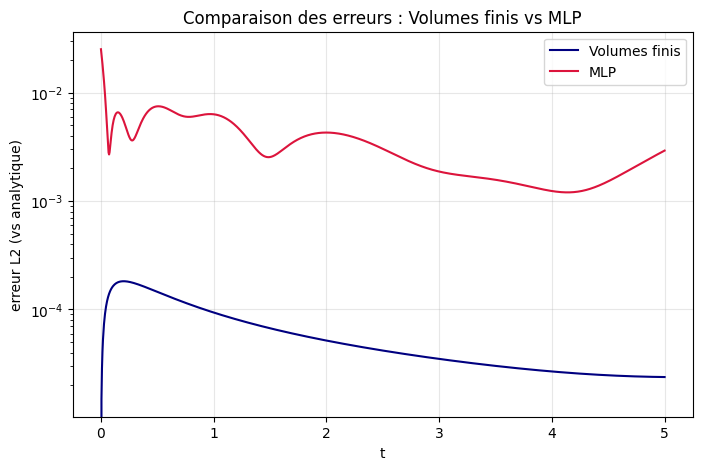

In [25]:
# --- 1) Grille de référence : on ressimule les Volumes Finis avec les paramètres de base (A, x0, sigma, D, alpha) pour avoir une solution
#     numérique fiable à comparer sur toute la grille (x, t).
x_grille, t_grille, U_vf_grille = u_volume_finie(A=A, x0=x0, sigma=sigma, D=D, alpha=alpha, L=L, T=T, Nx=Nx)

# --- 2) On construit le produit cartésien (x, t) de toute la grille ---
#     meshgrid donne deux tableaux 2D de forme (len(t_grille), len(x_grille)) :
#     X_mesh[i,j] = x_grille[j], T_mesh[i,j] = t_grille[i]
X_mesh, T_mesh = np.meshgrid(x_grille, t_grille)
x_flat = X_mesh.ravel()
t_flat = T_mesh.ravel()

# --- 3) IMPORTANT : on normalise (x, t) avec les MÊMES x_mean/x_std, ---
#     t_mean/t_std que ceux utilisés à l'entraînement. Le modèle n'a
#     appris qu'à interpréter des entrées normalisées, pas des (x, t) bruts.

x_flat_norm = (x_flat - x_mean) / x_std
t_flat_norm = (t_flat - t_mean) / t_std
entre_grille = torch.tensor(np.column_stack([x_flat_norm, t_flat_norm]), dtype=torch.float32)

model.eval()
with torch.no_grad():
    sortie_norm = model(entre_grille)

# --- 4) Dénormalisation : on inverse EXACTEMENT la transformation faite ---
#     avant l'entraînement (normalisation -> log). Le modèle prédit u en
#     "log normalisé", donc : dénormaliser -> exp -> retrancher eps.
u_log_pred = sortie_norm.numpy().flatten() * u_std + u_mean
U_mlp_grille = (np.exp(u_log_pred) - eps).reshape(X_mesh.shape)

# --- Graphe de comparaison des trois  solutions ---
temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=2.5, label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_solutions.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Erreurs globales des deux méthodes par rapport à l'analytique, sur la grille ---
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
dx_grille = x_grille[1] - x_grille[0]

erreur_vf = U_vf_grille - U_exacte_grille
erreur_mlp = U_mlp_grille - U_exacte_grille

L2_vf = np.sqrt(dx_grille * np.sum(erreur_vf**2, axis=1))
L2_mlp = np.sqrt(dx_grille * np.sum(erreur_mlp**2, axis=1))

print(f"Erreur L2 max — Volumes finis : {L2_vf.max():.6f}")
print(f"Erreur L2 max — MLP           : {L2_mlp.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_grille, L2_vf, label="Volumes finis", color='navy')
plt.plot(t_grille, L2_mlp, label="MLP", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur L2 (vs analytique)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Comparaison des erreurs : Volumes finis vs MLP")
plt.savefig('comparaison_erreurs_L2.png', dpi=300, bbox_inches='tight')
plt.show()

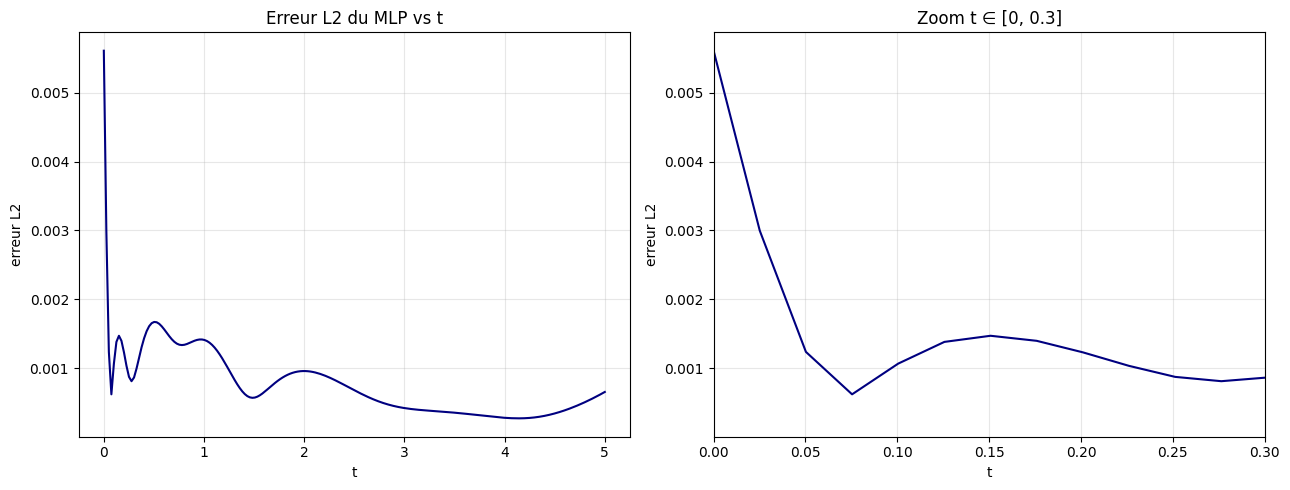

In [28]:
# --- Erreur du MLP en fonction du temps, avec un zoom sur le choc initial ---
# On reconstruit une grille fine en x (indépendante de x_grille) pour
# évaluer précisément l'évolution de l'erreur au cours du temps.
t_test_vals = np.linspace(0, T, 200)
x_grille_err = np.linspace(-L, L, Nx)

erreurs_L2_t, erreurs_Linf_t = [], []
for ti in t_test_vals:
    # normalisation identique à l'entraînement
    x_n = (x_grille_err - x_mean) / x_std
    t_n = (np.full_like(x_grille_err, ti) - t_mean) / t_std
    Xg = torch.tensor(np.column_stack([x_n, t_n]), dtype=torch.float32)
    with torch.no_grad():
        u_log_g = model(Xg).numpy().flatten() * u_std + u_mean
    u_pred_g = np.exp(u_log_g) - eps
    u_exacte_g = u_analytique(x_grille_err, ti, A, x0, sigma, D, alpha)
    diff = u_pred_g - u_exacte_g
    erreurs_L2_t.append(np.sqrt(np.mean(diff**2)))
    erreurs_Linf_t.append(np.max(np.abs(diff)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_test_vals, erreurs_L2_t, color='navy')
axes[0].set_title("Erreur L2 du MLP vs t")
axes[1].plot(t_test_vals, erreurs_L2_t, color='navy')
axes[1].set_xlim(0, 0.3)  # zoom sur le choc initial
axes[1].set_title("Zoom t ∈ [0, 0.3]")
for ax in axes:
    ax.set_xlabel('t'); ax.set_ylabel('erreur L2'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('erreur_MLP_vs_t.png', dpi=300, bbox_inches='tight')
plt.show()

### 18. Test de généralisation du MLP à d'autres régimes physiques

Le MLP a été entraîné sur un seul jeu de paramètres physiques (D, alpha,
sigma fixés). On l'évalue ici, **sans le ré-entraîner**, sur dix scénarios
différents (diffusion rapide/lente, décroissance forte/nulle, front raide
ou large, CFL limite...) pour voir s'il généralise ou s'il est simplement
surajusté au régime d'entraînement.

Pour chaque scénario, on ressimule une solution Volumes Finis de référence
(propre à ce scénario) et on compare aux prédictions figées du MLP.
On s'attend à ce que l'écart grandisse dès que le scénario s'éloigne du
régime sur lequel le MLP a appris ce sera un bon argument en faveur des
PINNs, introduits juste après, qui intègrent directement l'EDP et peuvent
être ré-entraînés pour n'importe quel jeu (D, alpha, sigma).

espace de temps 0.004500000000000001 espace de position 0.1


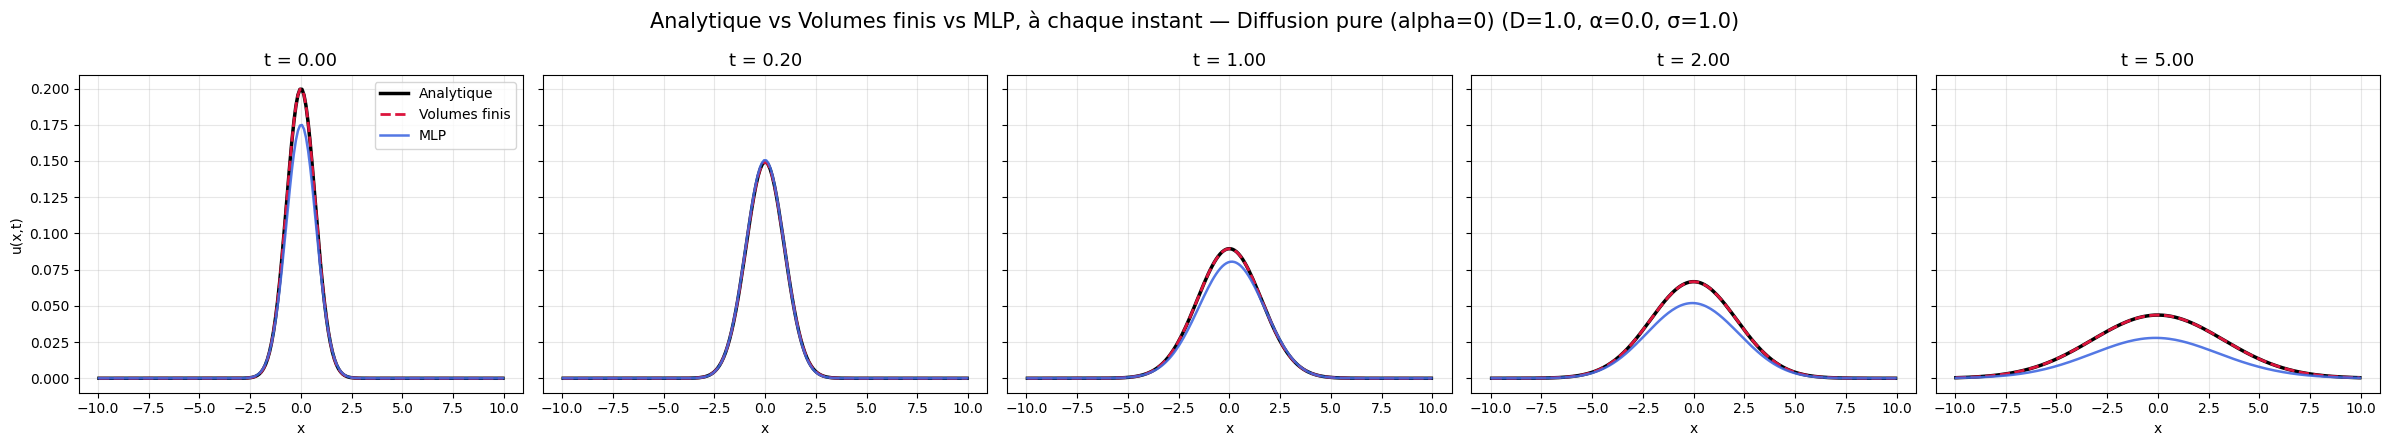

espace de temps 0.022500000000000006 espace de position 0.1


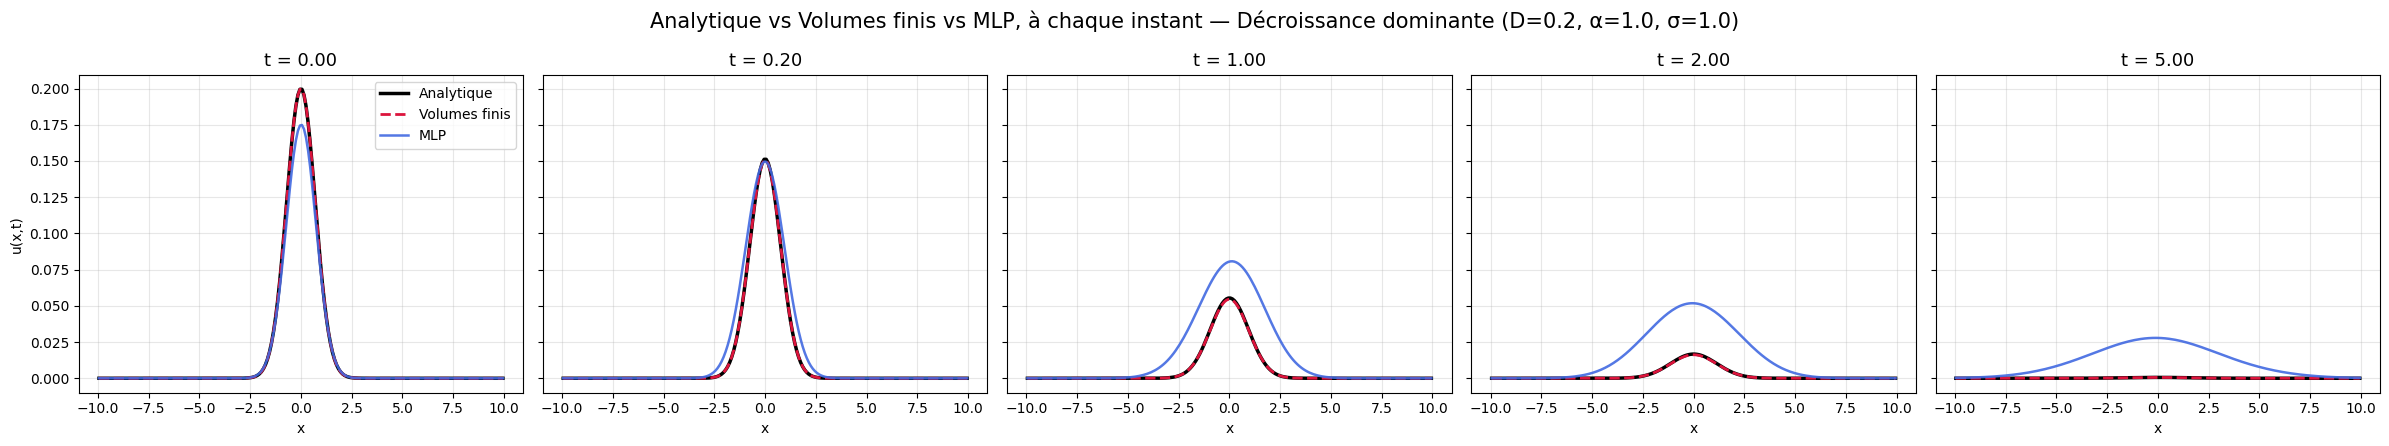

espace de temps 0.0009000000000000003 espace de position 0.1


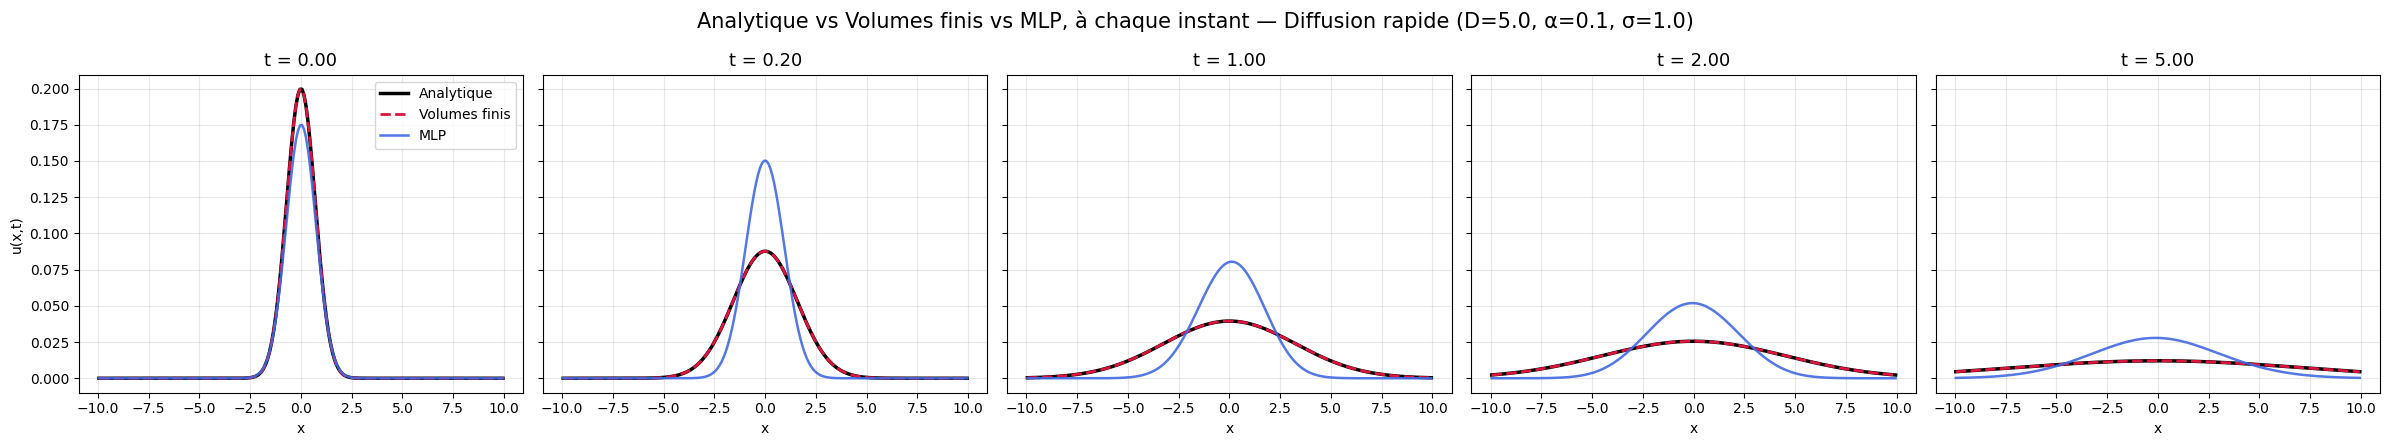

espace de temps 0.004500000000000001 espace de position 0.1


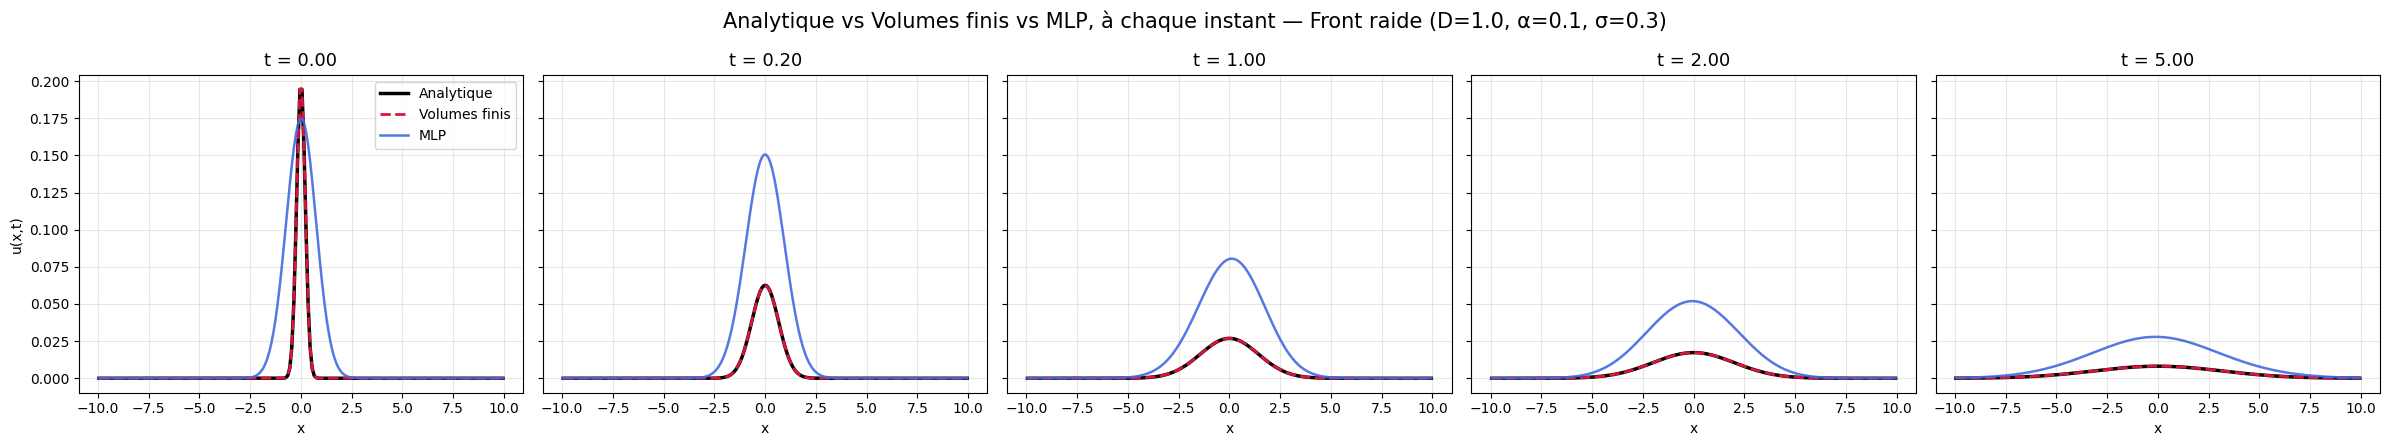

espace de temps 0.004500000000000001 espace de position 0.1


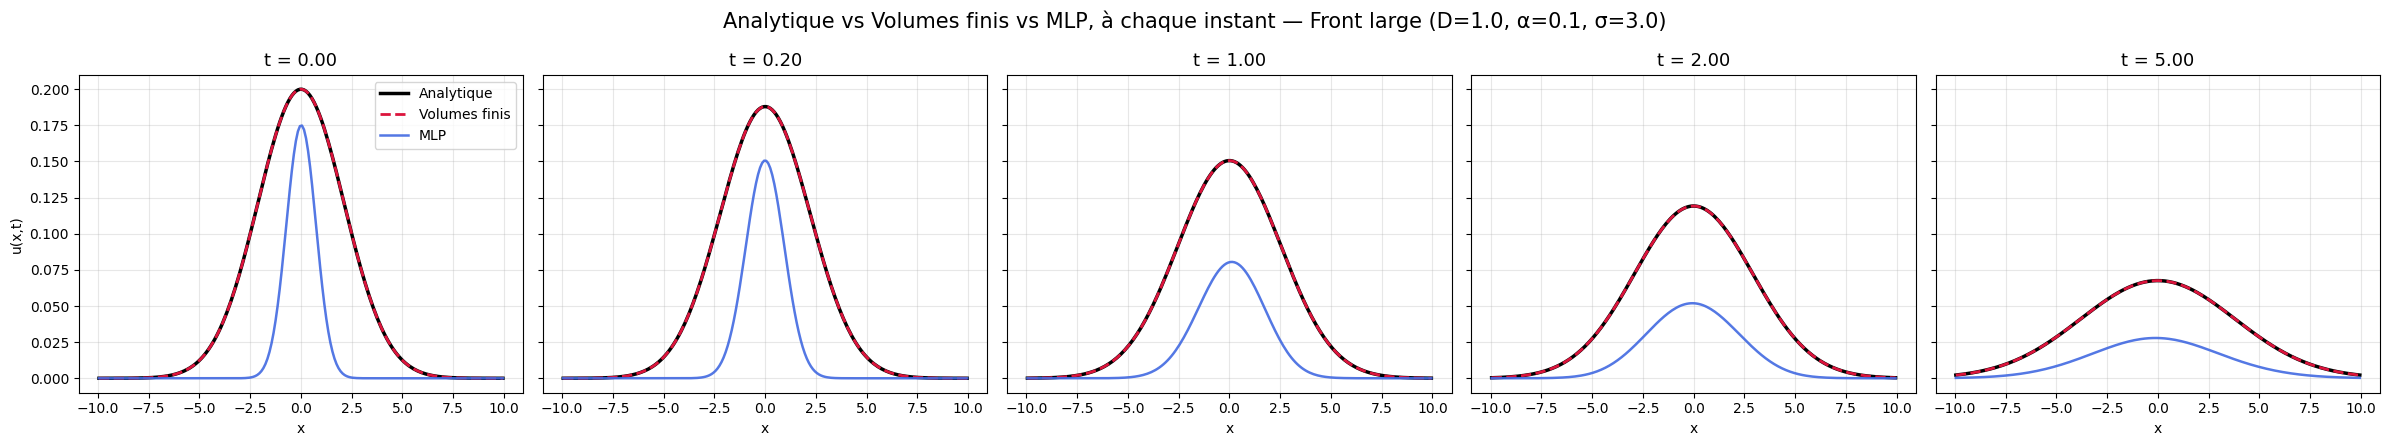

espace de temps 0.09000000000000002 espace de position 0.1


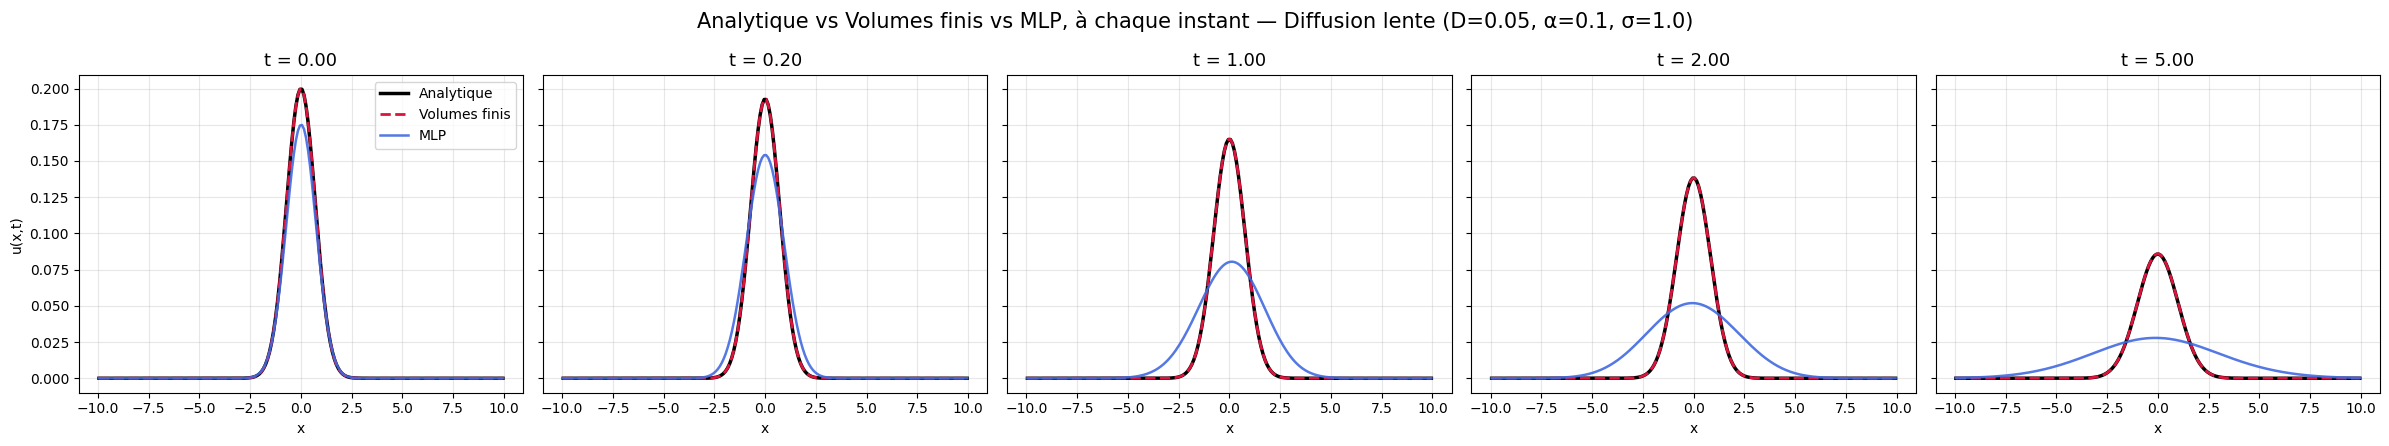

espace de temps 0.0009000000000000003 espace de position 0.1


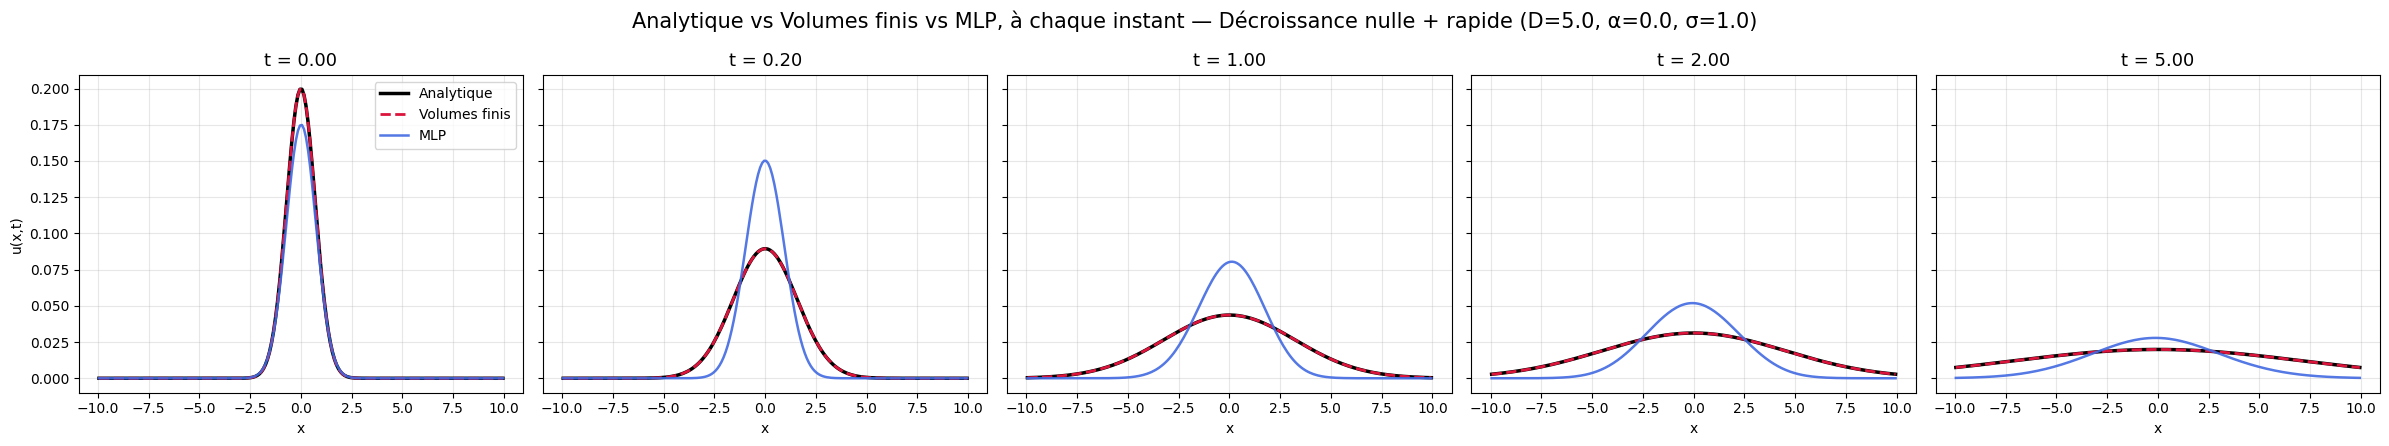

espace de temps 0.09000000000000002 espace de position 0.1


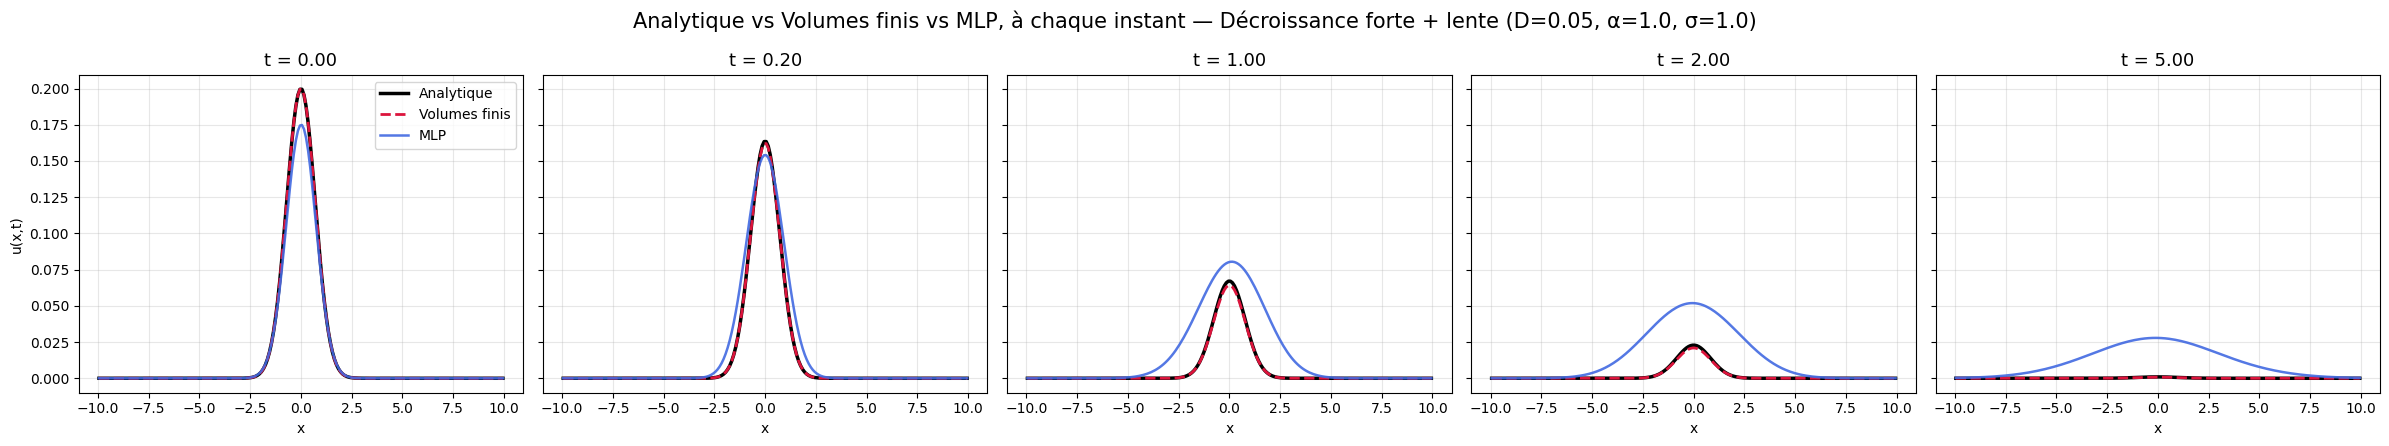

espace de temps 0.005000000000000001 espace de position 0.1


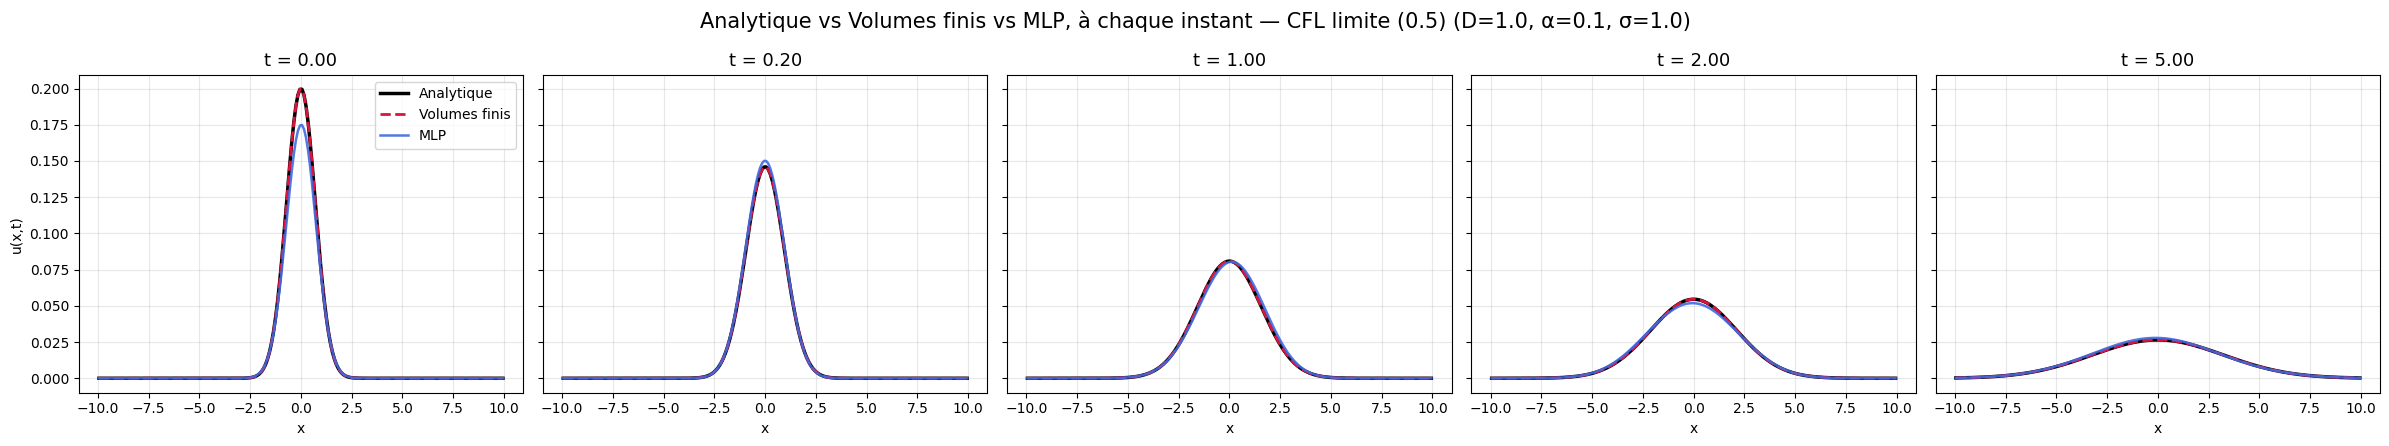

espace de temps 0.006000000000000001 espace de position 0.1


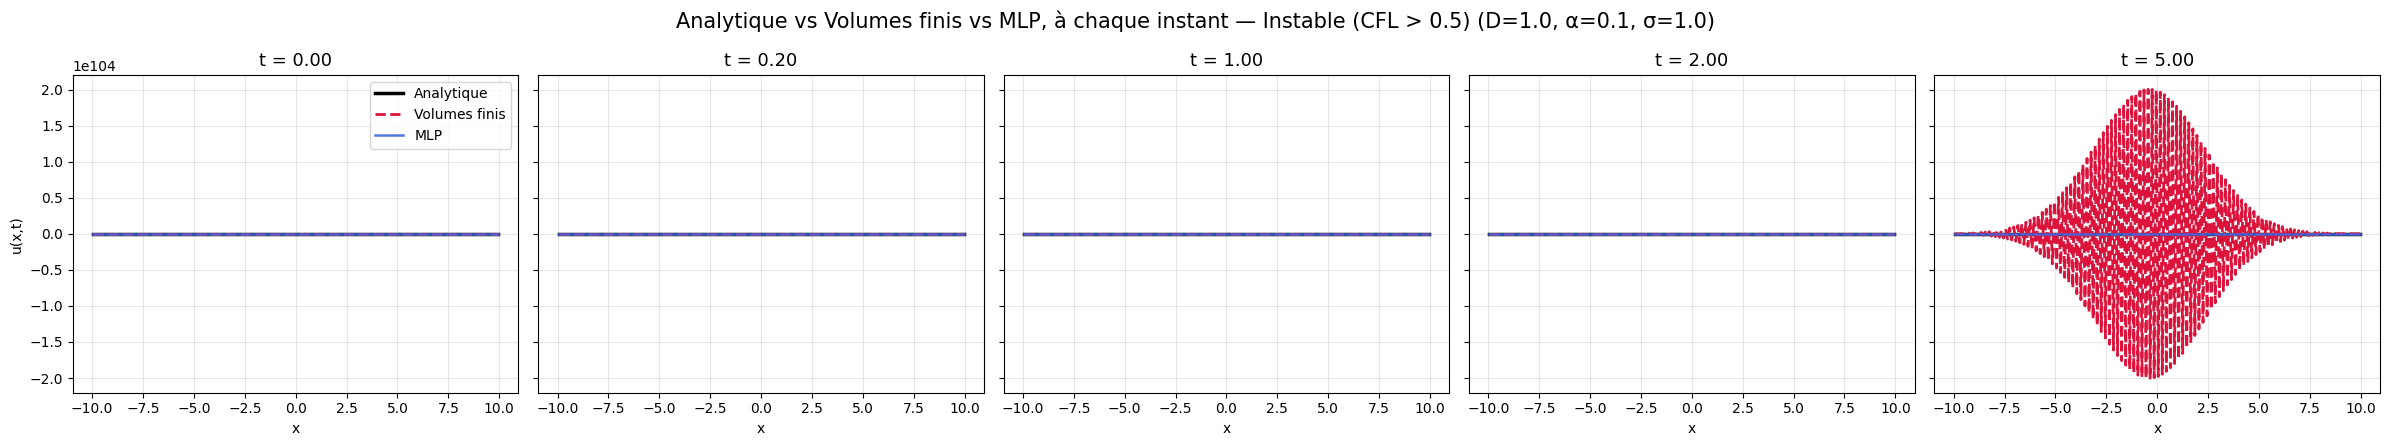

In [26]:

temps_a_tracer = [0.0, 0.2, 1.0, 2.0, 5.0]

for nom, p in scenarios.items():
    x_VF, t_VF, U_num = u_volume_finie(A=A, x0=x0, sigma=p['sigma'], D=p['D'],
                                        alpha=p['alpha'], L=L, T=T, Nx=Nx, clf=p['clf'])

    fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(24, 4.5), sharey=True)

    for col, ti in enumerate(temps_a_tracer):
        ax = axes[col]
        idx = np.argmin(np.abs(t_VF - ti))

        # Analytique
        u_exacte_ti = u_analytique(x_VF, t_VF[idx], A, x0, p['sigma'], p['D'], p['alpha'])

        # MLP
        x_gn = (x_VF - x_mean) / x_std
        t_gn = (np.full_like(x_VF, t_VF[idx]) - t_mean) / t_std
        Xg = torch.tensor(np.column_stack([x_gn, t_gn]), dtype=torch.float32)
        with torch.no_grad():
            u_log_pred = model(Xg).numpy().flatten() * u_std + u_mean
        u_pred = np.exp(u_log_pred) - eps

        ax.plot(x_VF, u_exacte_ti, color='black', linewidth=2.5, label='Analytique')
        ax.plot(x_VF, U_num[idx, :], color='crimson', linestyle='--', linewidth=2, label='Volumes finis')
        ax.plot(x_VF, u_pred, color='royalblue', linewidth=1.8, alpha=0.9, label='MLP')

        ax.set_title(f"t = {ti:.2f}", fontsize=13)
        ax.set_xlabel('x')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel('u(x,t)')
            ax.legend(fontsize=10)

    plt.suptitle(f"Analytique vs Volumes finis vs MLP, à chaque instant — {nom} "
                 f"(D={p['D']}, α={p['alpha']}, σ={p['sigma']})", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"comparaison_{nom.replace(' ', '_').replace('(', '').replace(')', '')}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

## Partie PINN — Physics-Informed Neural Network

Contrairement au MLP (purement supervisé), le PINN apprend en minimisant
un résidu de l'EDP elle-même, en plus de quelques données (condition
initiale + conditions aux limites). Le résidu est calculé par
différentiation automatique (`torch.autograd`) :

R(x, t) = ∂u/∂t − D ∂²u/∂x² + αu

La fonction de coût combine deux termes (cf. section 8 du sujet) :

L = L_data + λ · L_PDE,   où L_PDE = (1/N) Σᵢ R(xᵢ, tᵢ)²

Contrairement au MLP, le PINN reçoit D et alpha comme paramètres du calcul
du résidu (pas comme entrées du réseau) : on peut donc le ré-entraîner
pour n'importe quel scénario physique, ce que le MLP ne pouvait pas faire.

In [27]:
# --- Réseau du PINN : 2 entrées (x, t) -> 1 sortie u ---------------------
# Même architecture que le MLP (3 couches cachées, 32 neurones, tanh),
# mais la sortie passe par softplus() pour garantir u >= 0 en tout point
# (le taux de chômage relatif ne peut pas être négatif). tanh est choisi
# aussi pour les couches cachées. ses dérivées secondes ne
# s'annulent pas, ce qui est indispensable pour calculer u_xx via autograd.
class PINN(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))

### Résidu
 Résidu de l'EDP : R = u_t - D*u_xx + alpha*u 
 On calcule les dérivées de u par rapport à x et t par différentiation
automatique (et non par différences finies) :
  1) requires_grad_(True) sur x et t : on demande à PyTorch de garder
     la trace des opérations pour pouvoir dériver par rapport à elles ;
  2) u_t, u_x : dérivées premières (torch.autograd.grad) ;
  3) u_xx : dérivée seconde, obtenue en dérivant u_x par rapport à x
     une seconde fois (create_graph=True est nécessaire à chaque étape
     pour pouvoir dériver encore après) ;
  4) le résidu doit théoriquement être nul partout si u vérifie l'EDP :
      c'est ce résidu (au carré) que le PINN va chercher à minimiser.

In [28]:

def pinn_residual(model, x, t, D, alpha):   # ajouter D, alpha en paramètres
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u_pred = model(torch.cat([x, t], dim=1))
    u_t = torch.autograd.grad(u_pred, t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_t - D*u_xx + alpha*u_pred

In [29]:
# Condition initiale : u(x, 0) = A exp(-(x-x0)²/sigma²), échantillonnée
# en N_ic points aléatoires sur [-L, L]
N_ic = 300
x_ic = np.random.uniform(-L, L, N_ic)
t_ic = np.zeros(N_ic)
u_ic = u_analytique(x_ic, t_ic, A, x0, sigma, D, alpha)

x_ic = torch.tensor(x_ic, dtype=torch.float32).view(-1,1)
t_ic = torch.tensor(t_ic, dtype=torch.float32).view(-1,1)
u_ic = torch.tensor(u_ic, dtype=torch.float32).view(-1,1)
# Conditions aux limites : bords x = -L et x = +L, sur toute la durée T
# (ici on impose la solution analytique aux bords, ce qui revient à des
# conditions de Dirichlet non-homogènes)
N_bc = 300
t_bc = np.random.uniform(0, T, N_bc)
x_bc = np.where(np.arange(N_bc) < N_bc // 2, -L, L).astype(float)
u_bc = u_analytique(x_bc, t_bc, A, x0, sigma, D, alpha)

x_bc = torch.tensor(x_bc, dtype=torch.float32).view(-1,1)
t_bc = torch.tensor(t_bc, dtype=torch.float32).view(-1,1)
u_bc = torch.tensor(u_bc, dtype=torch.float32).view(-1,1)


In [30]:
# --- Concaténation des points IC et BC en un seul jeu "données" ---
x_data = torch.cat([x_ic, x_bc])
t_data = torch.cat([t_ic, t_bc])
u_data = torch.cat([u_ic, u_bc])

 ### La fonction de Loss
 Fonction de coût du PINN : L = L_data + lambda_pde * L_PDE 
L_data : erreur MSE classique entre u_prédit et u_exact, MAIS
  seulement aux points IC/BC (X_data), pas sur tout le domaine.
 - L_PDE : résidu moyen au carré, évalué sur des points "physiques"
  (X_phys) tirés aléatoirement dans tout le domaine à chaque epoch —
   ces points n'ont pas de u_exact associé, seule l'EDP doit y être
  satisfaite.
 lambda_pde pondère l'importance relative du respect de la physique
  par rapport à l'ajustement aux données IC/BC.

In [31]:
def pinn_loss(model, X_data, y_data, X_phys, lambda_pde, alpha, D):
    y_pred_data = model(X_data)
    loss_data = nn.MSELoss()(y_pred_data, y_data)
    pde_residual = pinn_residual(model, X_phys[:, 0:1], X_phys[:, 1:2], D, alpha)  # ← passer explicitement
    loss_phys = torch.mean(pde_residual**2)
    return loss_data + lambda_pde * loss_phys, loss_data, loss_phys

In [32]:
# --- Hyperparamètres d'entraînement du PINN ---------------------------
epochs = 5000       # nombre d'epochs pour la phase Adam
lr = 1e-3            # taux d'apprentissage Adam
lambda_pde = 8.0      # poids du terme physique dans la loss (cf. cellule 59)
print_every = 250


### Boucle d'entraînement (phase 1 : Adam) 
 À CHAQUE epoch, on tire N_r = 1000 nouveaux points de collocation
 (x_r, t_r) aléatoires dans le domaine : contrairement aux points
 IC/BC (fixes), les points physiques changent à chaque itération.
 Cela évite que le PINN "apprenne par cœur" un jeu fixe de points et
 l'oblige à satisfaire l'EDP partout dans le domaine, pas seulement
 en quelques endroits.

In [34]:
def train(model, X_data, y_data, epochs=epochs, lr=lr, lambda_pde=lambda_pde):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    torch.manual_seed(0)
    for epoch in range(epochs+1):
        model.train()
        optimizer.zero_grad()

        N_r = 1000
        x_r = torch.tensor(np.random.uniform(-L, L, N_r), dtype=torch.float32).view(-1,1)
        t_r = torch.tensor(np.random.uniform(0, T, N_r), dtype=torch.float32).view(-1,1)
        X_phys = torch.cat([x_r, t_r], dim=1)

        loss_total, loss_data, loss_phys = pinn_loss(model, X_data, y_data, X_phys, lambda_pde, alpha, D)
        loss_total.backward()
        optimizer.step()
        hist['total_loss'].append(loss_total.item())
        hist['data_loss'].append(loss_data.item())
        hist['phys_loss'].append(loss_phys.item())

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Data: {loss_data.item():.6f} | Phys: {loss_phys.item():.6f} | Total: {loss_total.item():.6f}")

    
    return model

In [35]:
# --- Lancement de l'entraînement (phase Adam) ---
hist = {'total_loss': [], 'data_loss': [], 'phys_loss': []}  # historique pour les courbes de convergence
X_data = torch.cat([x_data, t_data], dim=1)
pinn = PINN(hidden_dim=32)
pinn = train(pinn, X_data, u_data)

Epoch    0 | Data: 0.375388 | Phys: 0.005602 | Total: 0.420202
Epoch  250 | Data: 0.001951 | Phys: 0.000007 | Total: 0.002005
Epoch  500 | Data: 0.001605 | Phys: 0.000003 | Total: 0.001626
Epoch  750 | Data: 0.001526 | Phys: 0.000002 | Total: 0.001544
Epoch 1000 | Data: 0.001442 | Phys: 0.000003 | Total: 0.001470
Epoch 1250 | Data: 0.000918 | Phys: 0.000043 | Total: 0.001265
Epoch 1500 | Data: 0.000440 | Phys: 0.000034 | Total: 0.000716
Epoch 1750 | Data: 0.000287 | Phys: 0.000021 | Total: 0.000451
Epoch 2000 | Data: 0.000198 | Phys: 0.000017 | Total: 0.000335
Epoch 2250 | Data: 0.000137 | Phys: 0.000009 | Total: 0.000210
Epoch 2500 | Data: 0.000097 | Phys: 0.000003 | Total: 0.000122
Epoch 2750 | Data: 0.000064 | Phys: 0.000003 | Total: 0.000091
Epoch 3000 | Data: 0.000043 | Phys: 0.000004 | Total: 0.000075
Epoch 3250 | Data: 0.000030 | Phys: 0.000001 | Total: 0.000041
Epoch 3500 | Data: 0.000019 | Phys: 0.000005 | Total: 0.000058
Epoch 3750 | Data: 0.000014 | Phys: 0.000001 | Total: 0

In [36]:
# --- Évaluation AVANT L-BFGS (juste après Adam) ---
def evaluer_pinn_sur_grille(model, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha):
    model.eval()
    with torch.no_grad():
        xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
        U_pred = model(xt_grille).numpy().reshape(X_mesh.shape)
    U_exact = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
    diff = U_pred - U_exact
    mse = np.mean(diff**2)
    l2 = np.sqrt(mse)
    linf = np.max(np.abs(diff))
    return U_pred, mse, l2, linf

U_pinn_grille_avant, MSE_avant, L2_avant, Linf_avant = evaluer_pinn_sur_grille(
    pinn, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha)

print(f"AVANT L-BFGS | MSE = {MSE_avant:.3e} | L2 = {L2_avant:.3e} | L∞ = {Linf_avant:.3e}")

AVANT L-BFGS | MSE = 2.832e-06 | L2 = 1.683e-03 | L∞ = 5.697e-03


In [37]:
# --- Sauvegarde du PINN entraîné (Adam + L-BFGS) ---
torch.save({
    'model_state_dict': pinn.state_dict(),
    'hidden_dim': 32,
    'D': D, 'alpha': alpha,
}, 'pinn_reference.pth')

print("PINN sauvegardé dans pinn_reference.pth")

PINN sauvegardé dans pinn_reference.pth


### fine-tuning avec L-BFGS(phase2) 
 Adam converge vite au début mais stagne près du minimum (bruit dû au
 tirage aléatoire des points physiques à chaque epoch). L-BFGS est un
 optimiseur de second ordre : plus lent par itération, mais capable
 d'affiner beaucoup plus finement une fois qu'on est proche d'un minimum
  d'où l'usage classique Adam (exploration) -> L-BFGS (raffinement)
 pour les PINNs (cf. Raissi et al., 2019, bibliographie du sujet).

 Contrairement à Adam, L-BFGS a besoin d'un gradient stable d'une
 itération à l'autre : on fixe donc les points de collocation une
 fois pour toute la phase (pas de rééchantillonnage à chaque itération),
 et on passe par une closure() car L-BFGS peut évaluer la fonction
 plusieurs fois par step (recherche linéaire "strong_wolfe").

In [38]:
# --- Phase 2 : fine-tuning L-BFGS après Adam ---
# On repart du modèle pinn déjà entraîné avec Adam (cellule 52).
# L-BFGS a besoin d'un gradient stable => on fixe les points de collocation
# une fois pour toute la phase (pas de rééchantillonnage à chaque itération).

N_r_lbfgs = 2000
x_r_lbfgs = torch.tensor(np.random.uniform(-L, L, N_r_lbfgs), dtype=torch.float32).view(-1, 1)
t_r_lbfgs = torch.tensor(np.random.uniform(0, T, N_r_lbfgs), dtype=torch.float32).view(-1, 1)
X_phys_lbfgs = torch.cat([x_r_lbfgs, t_r_lbfgs], dim=1)

optimizer_lbfgs = torch.optim.LBFGS(
    pinn.parameters(),
    lr=1.0,
    max_iter=500,
    max_eval=None,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_iter = [0]  # compteur mutable pour logger dans la closure

def closure():
    optimizer_lbfgs.zero_grad()
    loss_total, loss_data, loss_phys = pinn_loss(pinn, X_data, u_data, X_phys_lbfgs, lambda_pde, alpha, D)
    loss_total.backward()

    hist['total_loss'].append(loss_total.item())
    hist['data_loss'].append(loss_data.item())
    hist['phys_loss'].append(loss_phys.item())

    if lbfgs_iter[0] % 50 == 0:
        print(f"[L-BFGS] iter {lbfgs_iter[0]:4d} | Data: {loss_data.item():.3e} | "
              f"Phys: {loss_phys.item():.3e} | Total: {loss_total.item():.3e}")
    lbfgs_iter[0] += 1

    return loss_total

optimizer_lbfgs.step(closure)

print(f"\nLoss finale après L-BFGS : {hist['total_loss'][-1]:.3e}")

[L-BFGS] iter    0 | Data: 3.547e-06 | Phys: 8.993e-07 | Total: 1.074e-05
[L-BFGS] iter   50 | Data: 3.146e-08 | Phys: 1.642e-07 | Total: 1.345e-06
[L-BFGS] iter  100 | Data: 8.190e-09 | Phys: 5.423e-08 | Total: 4.420e-07

Loss finale après L-BFGS : 2.656e-07


In [39]:
# --- Évaluation APRÈS L-BFGS : comparaison avant/après affinage ---------
# Le tableau ci-dessous doit normalement montrer un gain net sur les
# trois métriques (MSE, L2, L∞) grâce au fine-tuning L-BFGS.
U_pinn_grille_apres, MSE_apres, L2_apres, Linf_apres = evaluer_pinn_sur_grille(
    pinn, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha)

print(f"APRÈS L-BFGS | MSE = {MSE_apres:.3e} | L2 = {L2_apres:.3e} | L∞ = {Linf_apres:.3e}")

print("\n--- Comparaison ---")
print(f"{'Métrique':10s} {'Avant':>12s} {'Après':>12s} {'Gain (facteur)':>16s}")
print(f"{'MSE':10s} {MSE_avant:12.3e} {MSE_apres:12.3e} {MSE_avant/MSE_apres:16.1f}")
print(f"{'L2':10s} {L2_avant:12.3e} {L2_apres:12.3e} {L2_avant/L2_apres:16.1f}")
print(f"{'L∞':10s} {Linf_avant:12.3e} {Linf_apres:12.3e} {Linf_avant/Linf_apres:16.1f}")

# On met à jour U_pinn_grille pour que les cellules suivantes (56, 58, 59...) 
# utilisent automatiquement le modèle affiné
U_pinn_grille = U_pinn_grille_apres

APRÈS L-BFGS | MSE = 6.049e-09 | L2 = 7.778e-05 | L∞ = 4.800e-04

--- Comparaison ---
Métrique          Avant        Après   Gain (facteur)
MSE           2.832e-06    6.049e-09            468.2
L2            1.683e-03    7.778e-05             21.6
L∞            5.697e-03    4.800e-04             11.9


### 22. Effet du L-BFGS, convergence et comparaison finale à 4 méthodes

On visualise d'abord l'apport du fine-tuning L-BFGS (Adam seul vs Adam +
L-BFGS), puis la convergence de l'entraînement (loss data vs loss physique),
et enfin on superpose les 4 solutions (Analytique, Volumes Finis, MLP, PINN)
pour conclure la comparaison prévue dans le sujet.

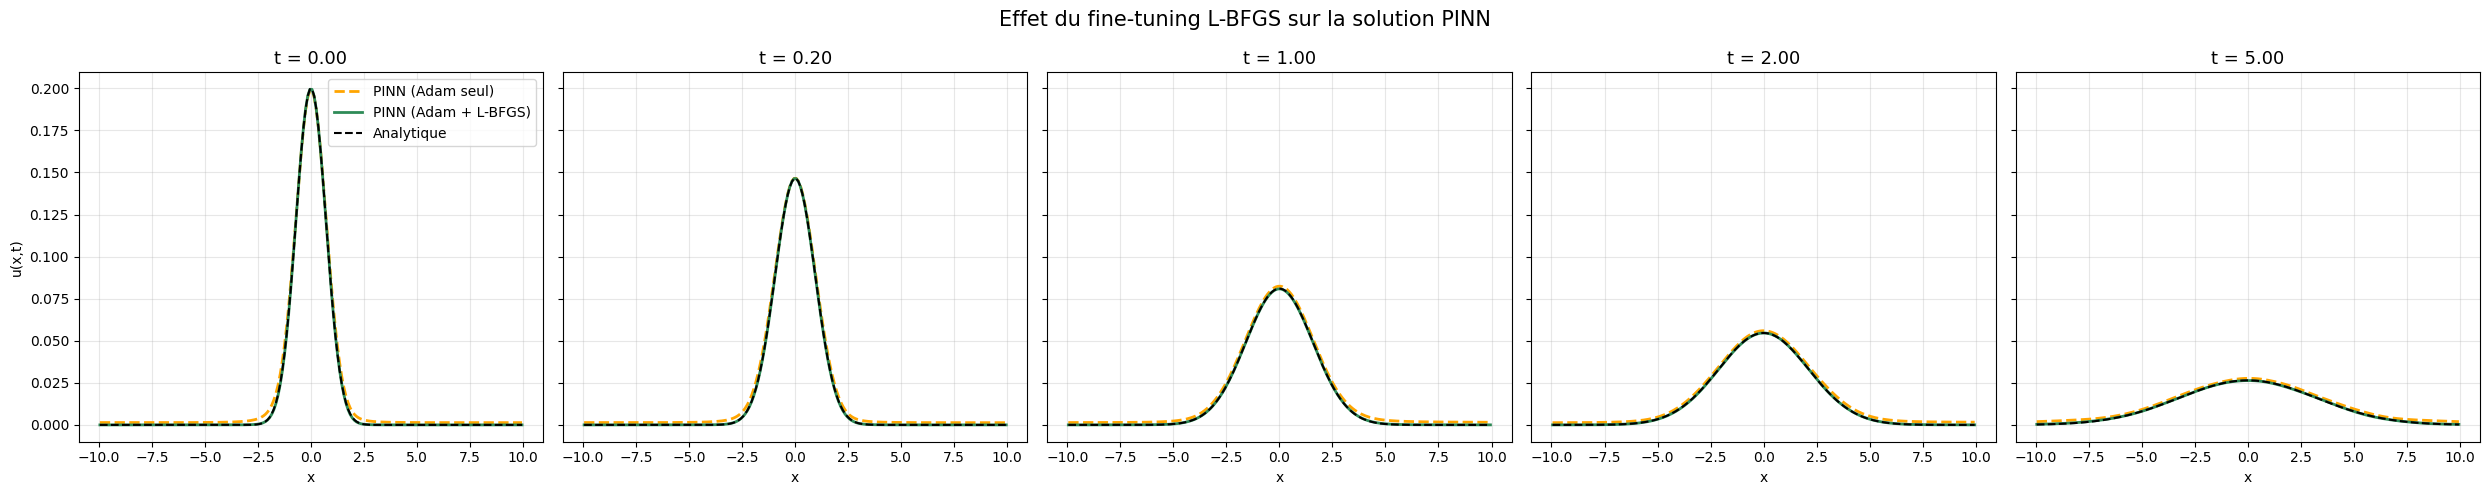

In [40]:
# On compare la solution PINN juste après Adam (avant_) à celle après
# L-BFGS (apres_) : le fine-tuning doit rapprocher la courbe verte
# (Adam+L-BFGS) de la courbe noire (analytique) par rapport à l'orange.
temps_a_tracer = [1e-4, 0.2, 1, 2, T]
fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    
    ax.plot(x_grille, U_pinn_grille_avant[idx, :], color='orange', linestyle='--', linewidth=2, label="PINN (Adam seul)")
    
    ax.plot(x_grille, U_pinn_grille_apres[idx, :], color='seagreen', linewidth=2, label="PINN (Adam + L-BFGS)")
    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=1.5, linestyle='--', label="Analytique")
    

    ax.set_title(f"t = {ti:.2f}", fontsize=13)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)')
axes[0].legend(fontsize=10)
plt.suptitle("Effet du fine-tuning L-BFGS sur la solution PINN", fontsize=15)
plt.tight_layout()
plt.savefig('effet_lbfgs.png', dpi=300, bbox_inches='tight')
plt.show()

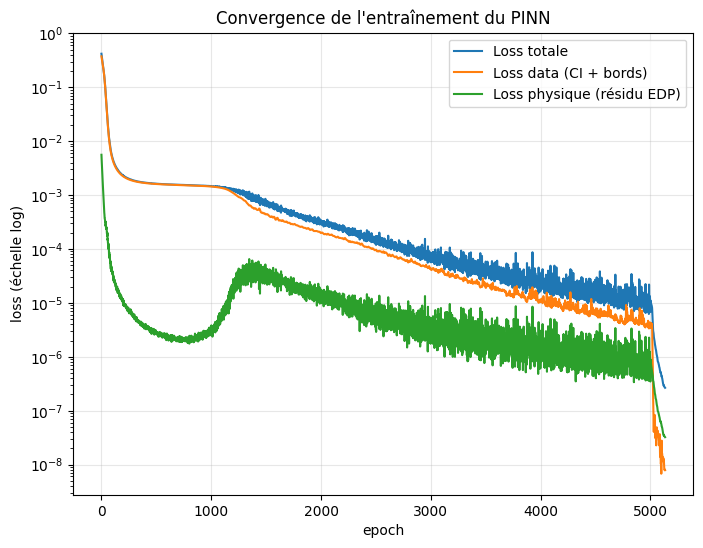

In [41]:
# --- Courbes de convergence : loss totale / data / physique -------------
# En échelle log : si loss_phys diminue nettement, le PINN a appris à
# satisfaire l'EDP ; si loss_data reste haute, il n'a pas bien ajusté
# la condition initiale / les bords.
plt.figure(figsize=(8, 6))
plt.semilogy(hist['total_loss'], label='Loss totale')
plt.semilogy(hist['data_loss'], label='Loss data (CI + bords)')
plt.semilogy(hist['phys_loss'], label='Loss physique (résidu EDP)')
plt.xlabel('epoch')
plt.ylabel('loss (échelle log)')
plt.title("Convergence de l'entraînement du PINN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

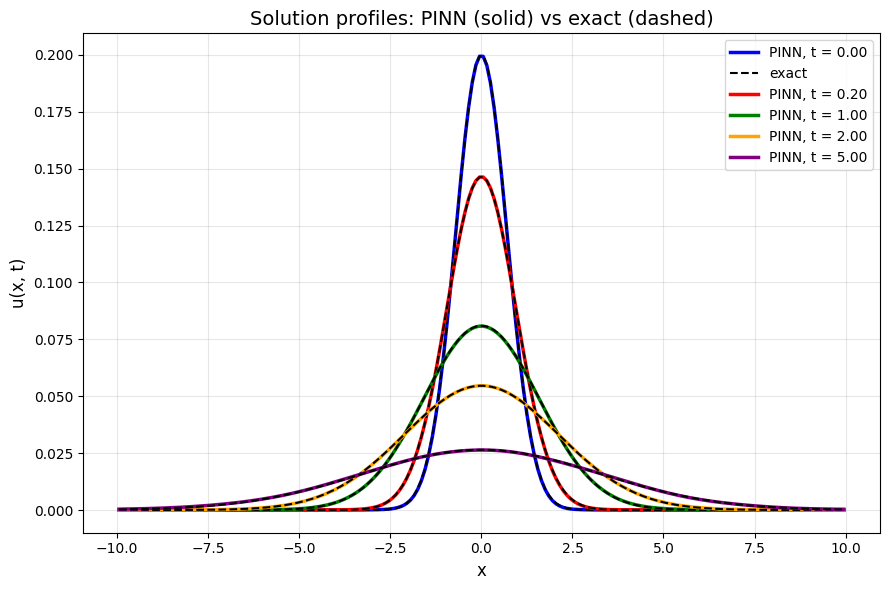

In [42]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = ["blue", "red", "green", "orange", "purple"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (c, ti) in enumerate(zip(colors, temps_a_tracer)):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    # Courbe PINN (pleine, colorée)
    ax.plot(x_grille, U_pinn_grille[idx, :], color=c, linewidth=2.5,
            label=f"PINN, t = {ti:.2f}")

    # Courbe exacte (pointillée noire) — une seule entrée dans la légende
    ax.plot(x_grille, U_exacte_ti, color='black', linestyle='--', linewidth=1.5,
            label="exact" if i == 0 else None)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x, t)', fontsize=12)
ax.set_title("Solution profiles: PINN (solid) vs exact (dashed)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparaison_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparaison finale à 4 courbes : Analytique / VF / MLP / PINN 

 U_vf_grille et U_mlp_grille viennent des cellules 50 et 66 : elles
 ne sont PAS recalculées ici, donc si tu changes A, D, alpha, sigma
 entre-temps, ces deux courbes seront désynchronisées de U_pinn_grille.

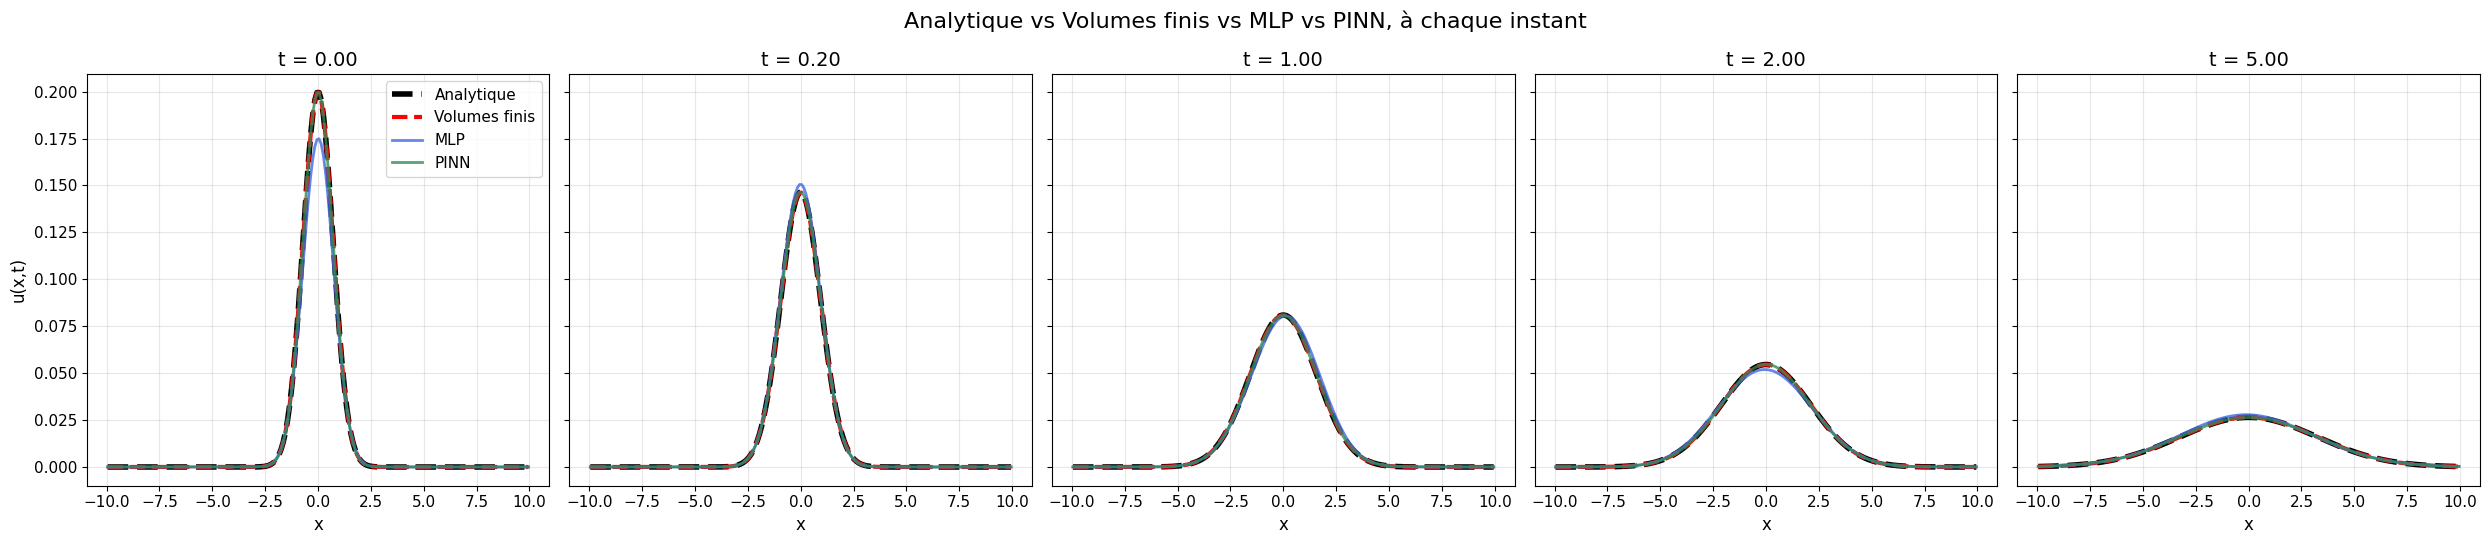

In [43]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]),
                              dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=4,linestyle='--', label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='red', linestyle='--', linewidth=3, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")
    ax.plot(x_grille, U_pinn_grille[idx, :], color='seagreen', linewidth=2, alpha=0.8, label="PINN")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP vs PINN, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_4_methodes.png', dpi=300, bbox_inches='tight')
plt.show()

 --- Vérification sur les points d'entraînement eux-mêmes (CI + bords) ---
 
 Sert de sanity check : si l'erreur élevée ici indiquerait que le PINN

 n'a même pas réussi à ajuster les données qu'il a vues directement.

In [44]:
pinn.eval()
with torch.no_grad():
    u_pred_train = pinn(X_data)
    err_train = (u_pred_train - u_data).numpy()

MSE_train = np.mean(err_train**2)
print(f"Erreur sur points d'entraînement (CI+bords) | MSE = {MSE_train:.3e}")

Erreur sur points d'entraînement (CI+bords) | MSE = 7.862e-09


### Erreur du PINN sur toute la grille (jamais vue pendant l'entraînement)

In [45]:
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
diff_grille = U_pinn_grille - U_exacte_grille

MSE_grille = np.mean(diff_grille**2)
L2_grille = np.sqrt(MSE_grille)
Linf_grille = np.max(np.abs(diff_grille))

print(f"Erreur sur grille complète (jamais vue)    | MSE = {MSE_grille:.3e}")
print(f"                                            | L2  = {L2_grille:.3e}")
print(f"                                            | L∞  = {Linf_grille:.3e}")

Erreur sur grille complète (jamais vue)    | MSE = 6.049e-09
                                            | L2  = 7.778e-05
                                            | L∞  = 4.800e-04


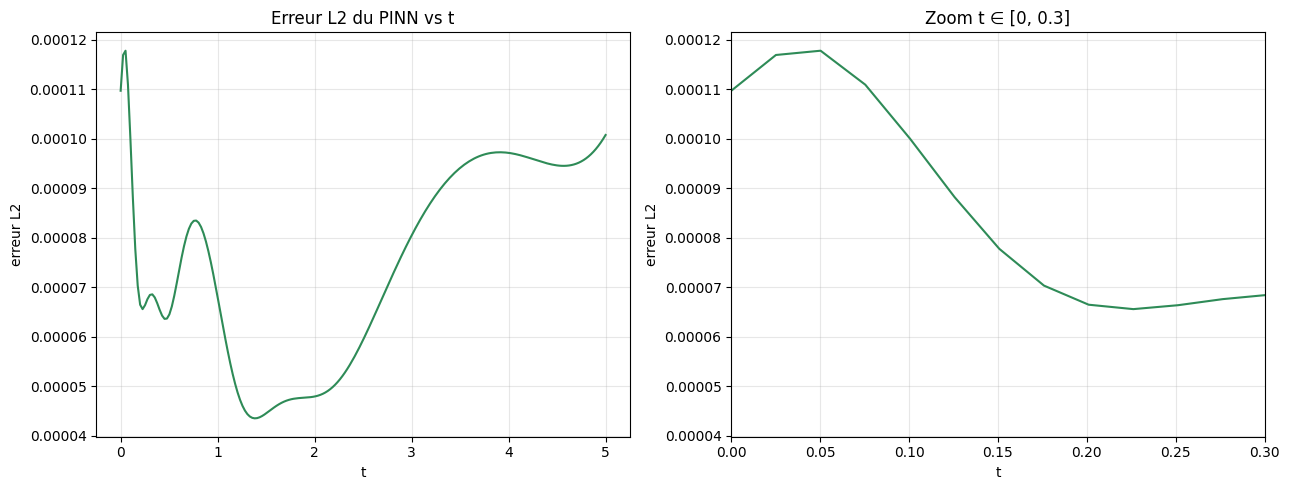

In [46]:
t_test_vals = np.linspace(0, T, 200)
x_grille_err = np.linspace(-L, L, Nx)

erreurs_L2_pinn, erreurs_Linf_pinn = [], []

pinn.eval()
for ti in t_test_vals:
    xt = torch.tensor(np.column_stack([x_grille_err, np.full_like(x_grille_err, ti)]),
                       dtype=torch.float32)
    with torch.no_grad():
        u_pred_g = pinn(xt).numpy().flatten()
    u_exacte_g = u_analytique(x_grille_err, ti, A, x0, sigma, D, alpha)
    diff = u_pred_g - u_exacte_g
    erreurs_L2_pinn.append(np.sqrt(np.mean(diff**2)))
    erreurs_Linf_pinn.append(np.max(np.abs(diff)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_test_vals, erreurs_L2_pinn, color='seagreen')
axes[0].set_title("Erreur L2 du PINN vs t")
axes[1].plot(t_test_vals, erreurs_L2_pinn, color='seagreen')
axes[1].set_xlim(0, 0.3)
axes[1].set_title("Zoom t ∈ [0, 0.3]")
for ax in axes:
    ax.set_xlabel('t'); ax.set_ylabel('erreur L2'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('erreur_PINN_vs_t.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparaison finale des erreurs L2 (vs analytique) des 3 méthodes ---
C'est LA figure de conclusion du stage : si le PINN a bien convergé,
sa courbe (verte) doit être globalement en dessous ou comparable à
celle du MLP, en particulier sur les scénarios hors régime d'entraînement.

Erreur L2 max — Volumes finis : 0.000182
Erreur L2 max — MLP           : 0.025164
Erreur L2 max — PINN          : 0.000532


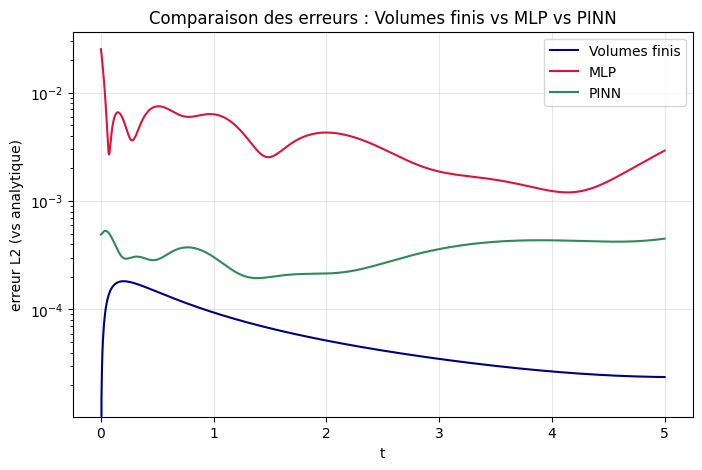

In [47]:
# --- Prédiction du PINN sur la même grille (t_grille, x_grille) ---
pinn.eval()
U_pinn_grille = np.zeros_like(U_exacte_grille)  # shape (n_t, n_x)

with torch.no_grad():
    for i, ti in enumerate(t_grille):
        xt = torch.tensor(
            np.column_stack([x_grille, np.full_like(x_grille, ti)]),
            dtype=torch.float32
        )
        U_pinn_grille[i, :] = pinn(xt).numpy().flatten()

# --- Erreurs globales des trois méthodes par rapport à l'analytique, sur la grille ---
erreur_vf = U_vf_grille - U_exacte_grille
erreur_mlp = U_mlp_grille - U_exacte_grille
erreur_pinn = U_pinn_grille - U_exacte_grille

L2_vf = np.sqrt(dx_grille * np.sum(erreur_vf**2, axis=1))
L2_mlp = np.sqrt(dx_grille * np.sum(erreur_mlp**2, axis=1))
L2_pinn = np.sqrt(dx_grille * np.sum(erreur_pinn**2, axis=1))

print(f"Erreur L2 max — Volumes finis : {L2_vf.max():.6f}")
print(f"Erreur L2 max — MLP           : {L2_mlp.max():.6f}")
print(f"Erreur L2 max — PINN          : {L2_pinn.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_grille, L2_vf, label="Volumes finis", color='navy')
plt.plot(t_grille, L2_mlp, label="MLP", color='crimson')
plt.plot(t_grille, L2_pinn, label="PINN", color='seagreen')
plt.xlabel('t')
plt.ylabel('erreur L2 (vs analytique)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Comparaison des erreurs : Volumes finis vs MLP vs PINN")
plt.savefig('comparaison_erreurs_L2_3methodes.png', dpi=300, bbox_inches='tight')
plt.show()

### 23. Version "scénario" du résidu et de la loss du PINN

Identique à `pinn_residual` / `pinn_loss` (cellules 56 et 59), mais avec
`D` et `alpha` comme arguments explicites à chaque appel, pour pouvoir
ré-entraîner un PINN différent pour chaque scénario physique dans la
boucle finale (cellule 78), sans dépendre des variables globales `D`, `alpha`.

In [ ]:

def pinn_loss_scenario(model, X_data, y_data, X_phys, D, alpha, lambda_pde=1.0):
    loss_data = nn.MSELoss()(model(X_data), y_data)
    R = pinn_residual(model, X_phys[:, 0:1], X_phys[:, 1:2], D, alpha)
    loss_phys = torch.mean(R**2)
    return loss_data + lambda_pde * loss_phys, loss_data, loss_phys

## Conclusion : Analytique vs Volumes Finis vs MLP vs PINN, sur tous les scénarios

Pour clore la comparaison, on reprend les dix scénarios physiques de la
section 18, et pour chacun on calcule les 4 solutions :
- **Analytique** et **Volumes Finis** : recalculées pour CE scénario (référence fiable) ;
- **MLP** : le modèle fixe entraîné une seule fois — on s'attend à ce qu'il
  se dégrade dès qu'on s'éloigne du régime d'entraînement ;
- **PINN** : ré-entraîné spécifiquement pour CE scénario (via `train_pinn_scenario`),
  car le résidu de l'EDP dépend de D et alpha — le PINN peut donc s'adapter
  à n'importe quel jeu de paramètres sans changer d'architecture.

C'est la démonstration attendue en conclusion du stage : le PINN combine
la flexibilité du Deep Learning avec le respect de la physique, là où le
MLP purement supervisé ne généralise pas.

In [63]:
from random import seed


def train_pinn_scenario(D, alpha, sigma, A=A, x0=x0, L=L, T=T,
                         epochs=2000, lr=1e-3, lambda_pde=1.0,
                         N_ic=200, N_bc=200, N_r=500, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = PINN(hidden_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- Points IC : mélange uniforme + concentré près de x0, proportionnel à sigma ---
    N_ic_focus = int(0.5 * N_ic)      # 50% concentrés près du pic
    N_ic_unif  = N_ic - N_ic_focus

    x_ic_unif  = np.random.uniform(-L, L, N_ic_unif)
    x_ic_focus = np.clip(np.random.normal(loc=x0, scale=sigma, size=N_ic_focus), -L, L)
    x_ic = np.concatenate([x_ic_unif, x_ic_focus])
    t_ic = np.zeros(N_ic)
    u_ic = u_analytique(x_ic, t_ic, A, x0, sigma, D, alpha)

    t_bc = np.random.uniform(0, T, N_bc)
    x_bc = np.where(np.arange(N_bc) < N_bc // 2, -L, L).astype(float)
    u_bc = u_analytique(x_bc, t_bc, A, x0, sigma, D, alpha)

    x_data = torch.tensor(np.concatenate([x_ic, x_bc]), dtype=torch.float32).view(-1, 1)
    t_data = torch.tensor(np.concatenate([t_ic, t_bc]), dtype=torch.float32).view(-1, 1)
    u_data = torch.tensor(np.concatenate([u_ic, u_bc]), dtype=torch.float32).view(-1, 1)
    X_data = torch.cat([x_data, t_data], dim=1)

    for epoch in range(epochs):
        optimizer.zero_grad()
        x_r = torch.tensor(np.random.uniform(-L, L, N_r), dtype=torch.float32).view(-1, 1)
        t_r = torch.tensor(np.random.uniform(0, T, N_r), dtype=torch.float32).view(-1, 1)
        X_phys = torch.cat([x_r, t_r], dim=1)

        loss_total, _, _ = pinn_loss_scenario(model, X_data, u_data, X_phys, D, alpha, lambda_pde)
        loss_total.backward()
        optimizer.step()

    return model

espace de temps 0.004500000000000001 espace de position 0.1


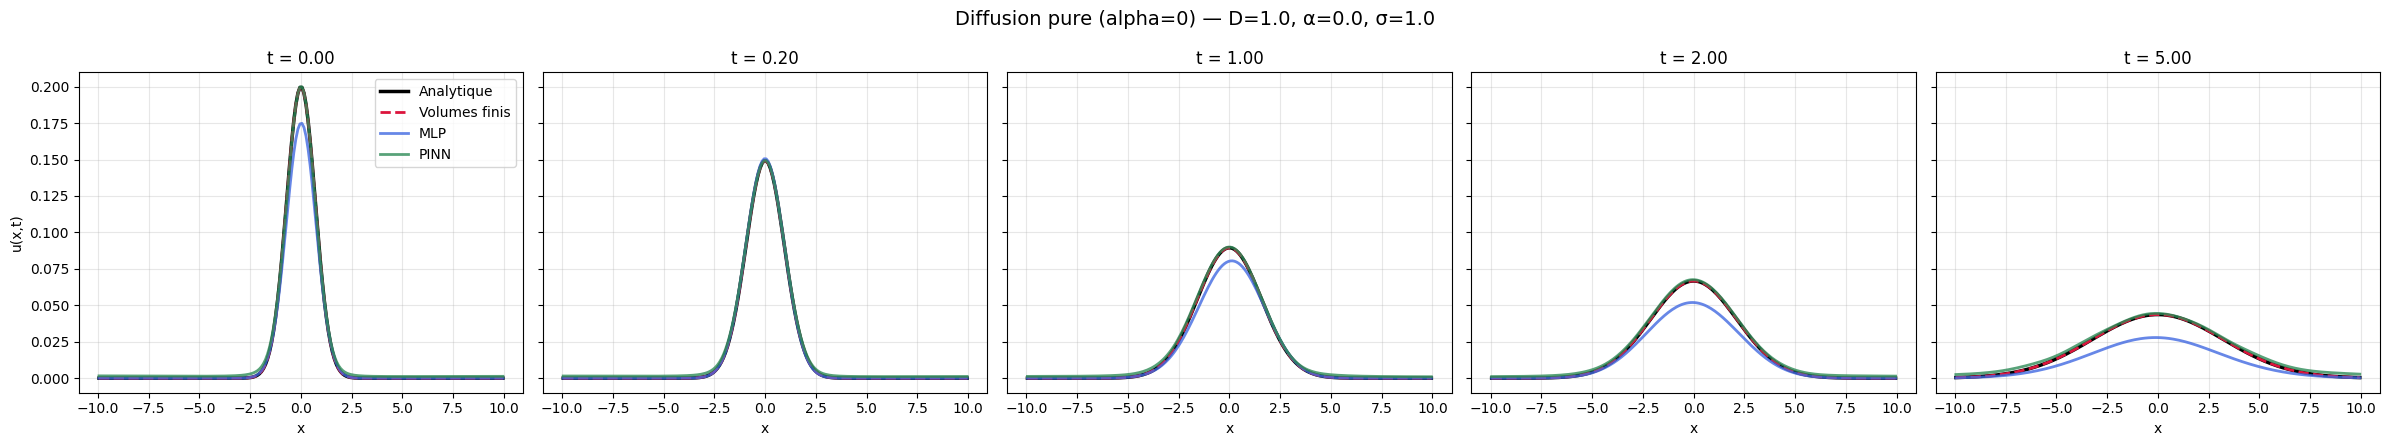

espace de temps 0.022500000000000006 espace de position 0.1


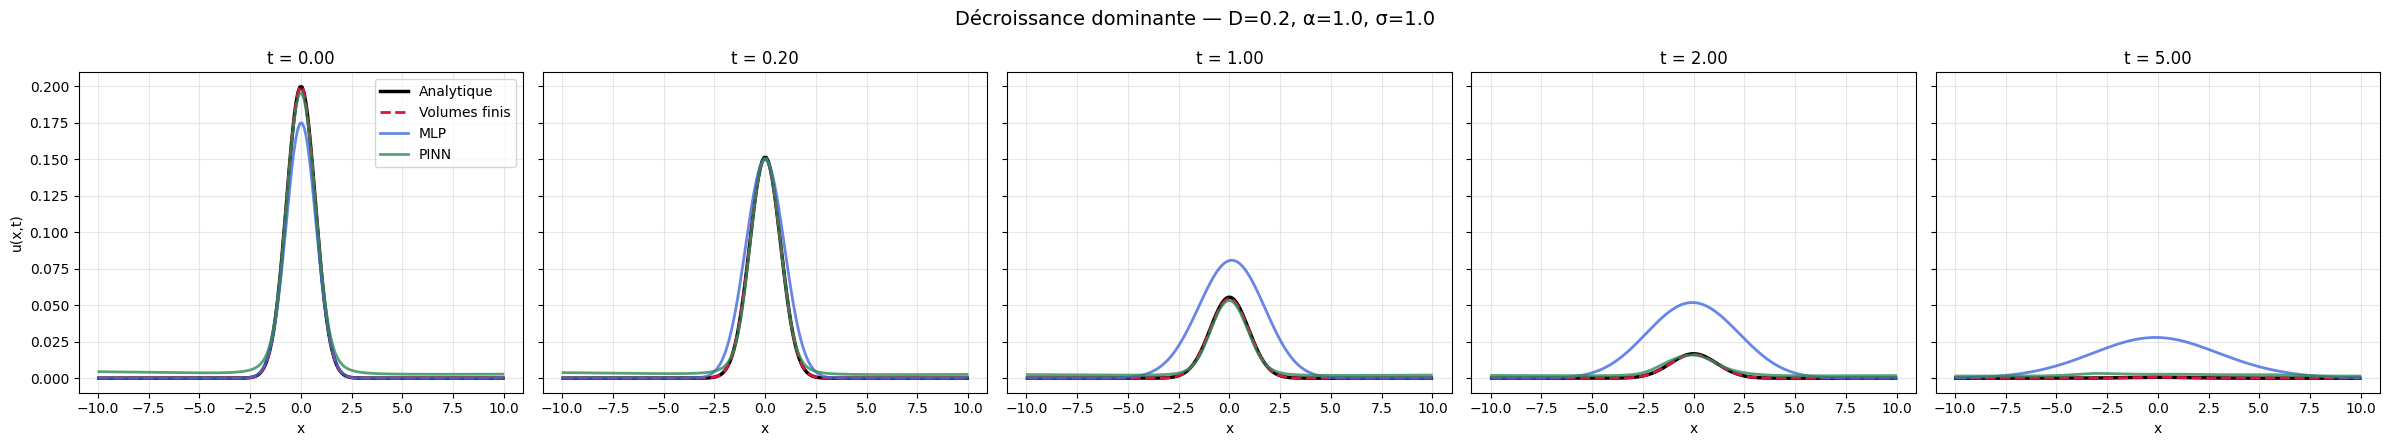

espace de temps 0.0009000000000000003 espace de position 0.1


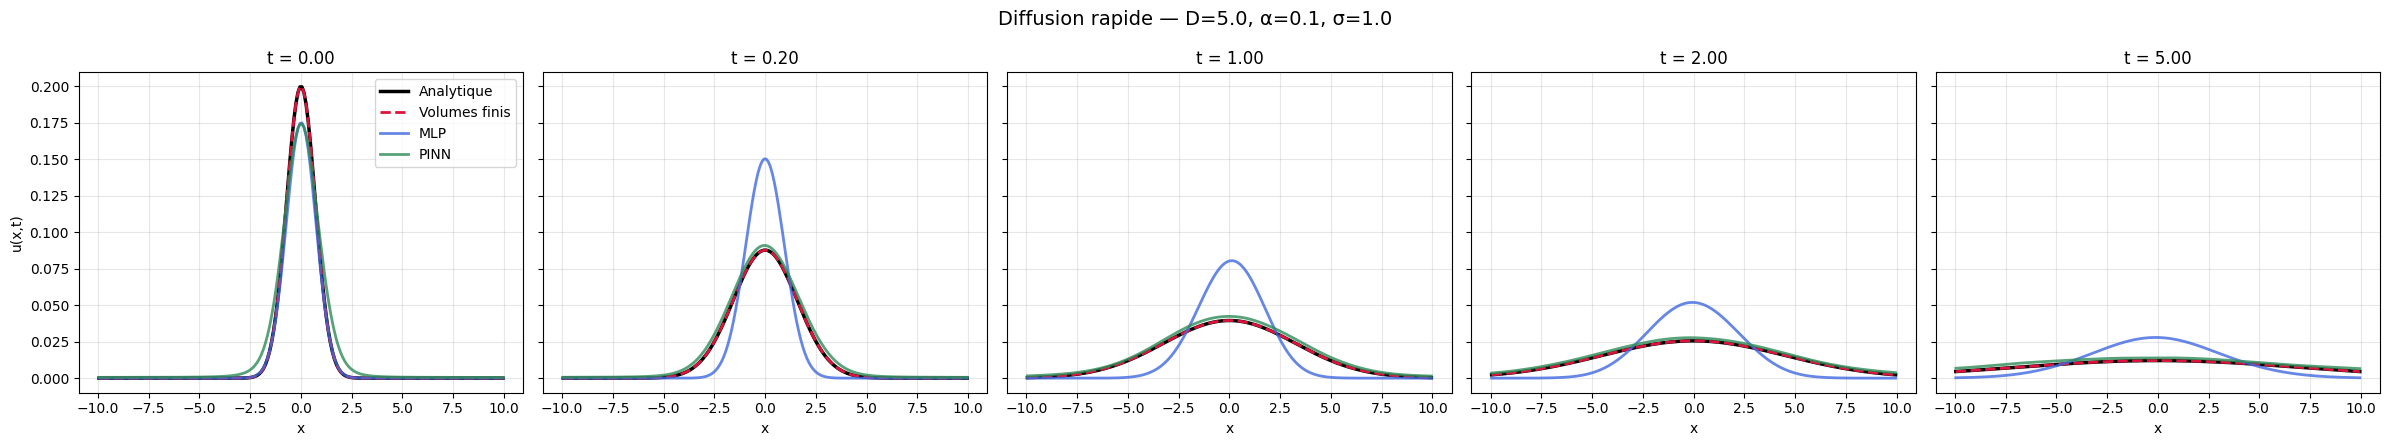

espace de temps 0.004500000000000001 espace de position 0.1


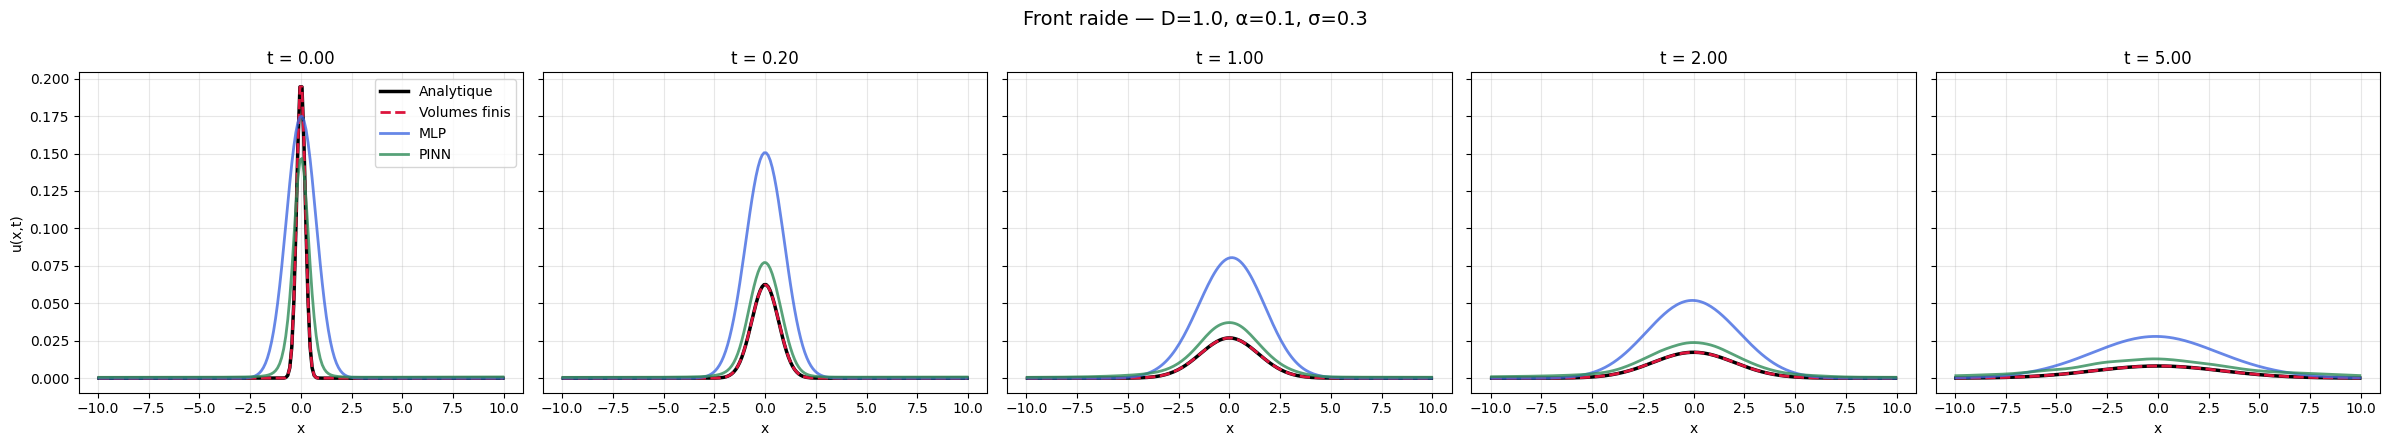

espace de temps 0.004500000000000001 espace de position 0.1


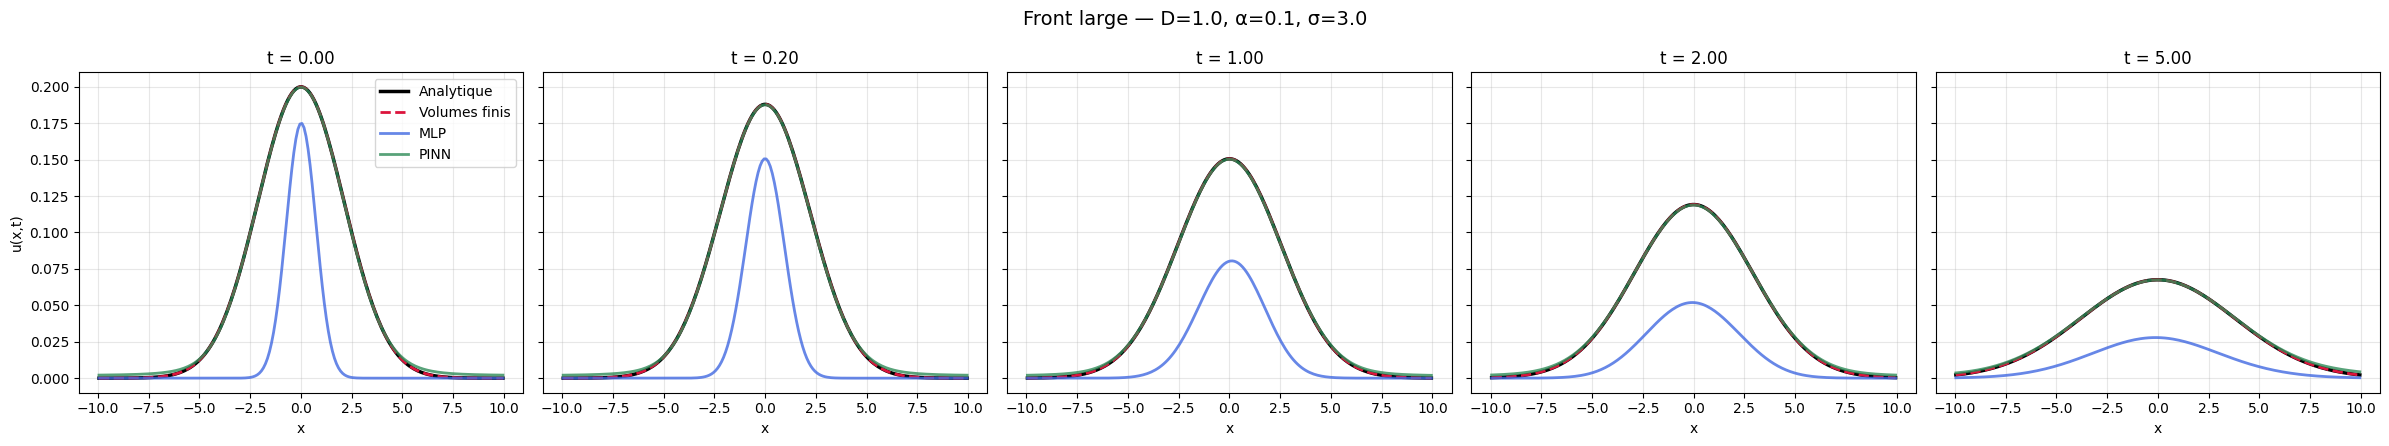

espace de temps 0.09000000000000002 espace de position 0.1


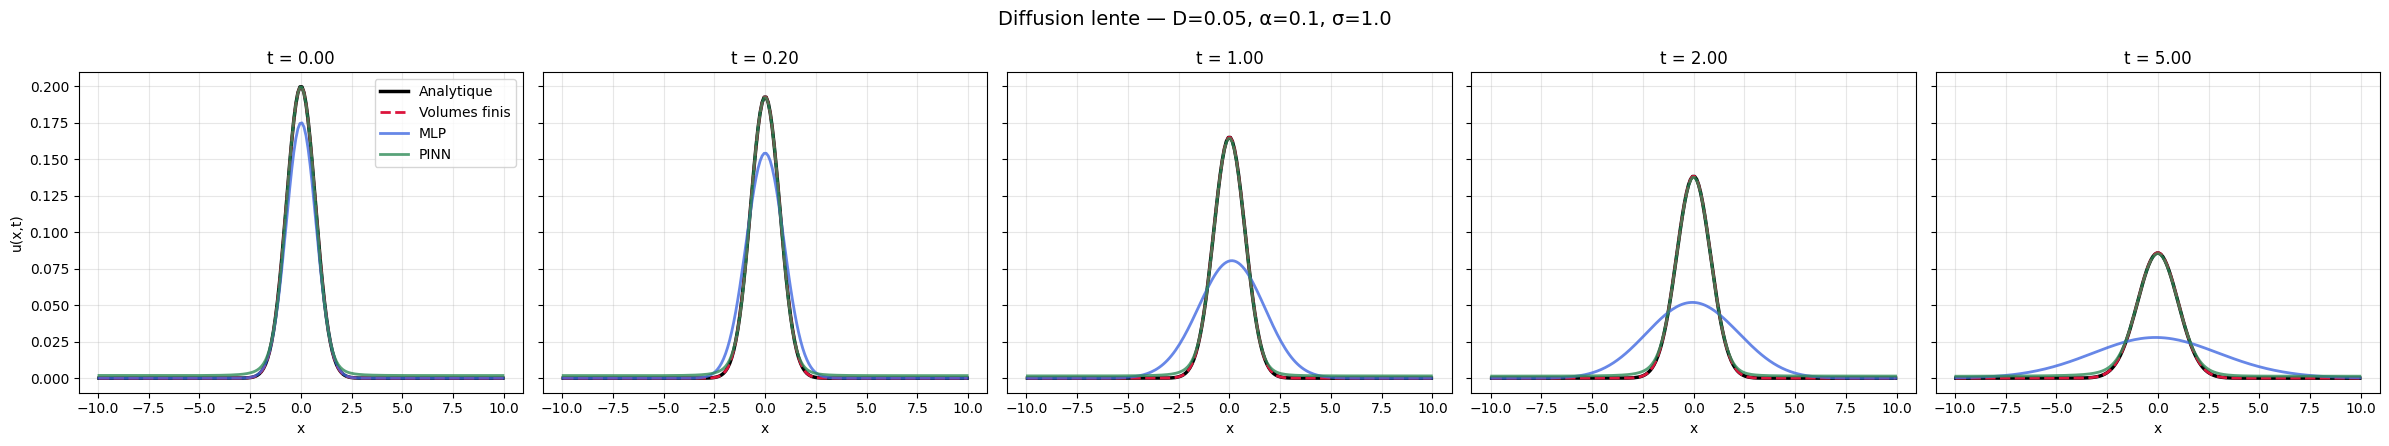

espace de temps 0.0009000000000000003 espace de position 0.1


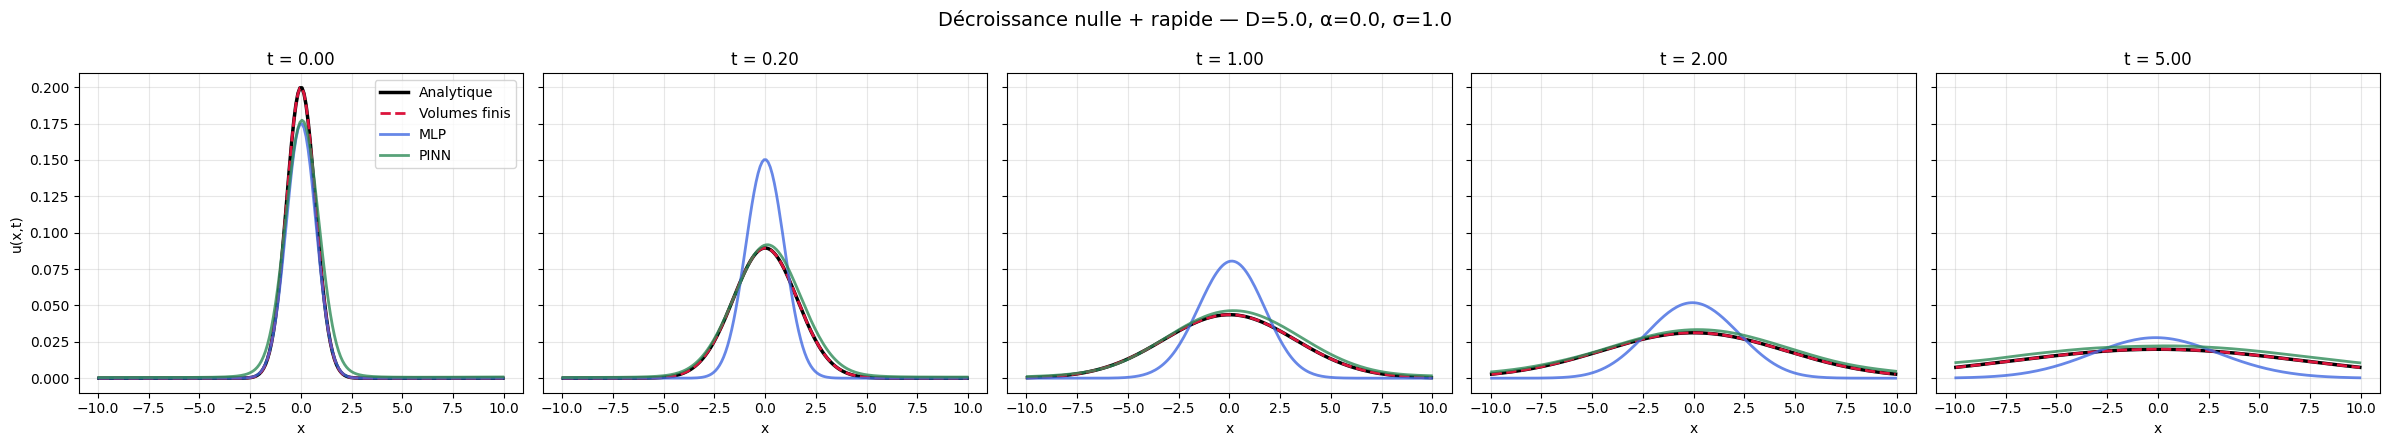

espace de temps 0.09000000000000002 espace de position 0.1


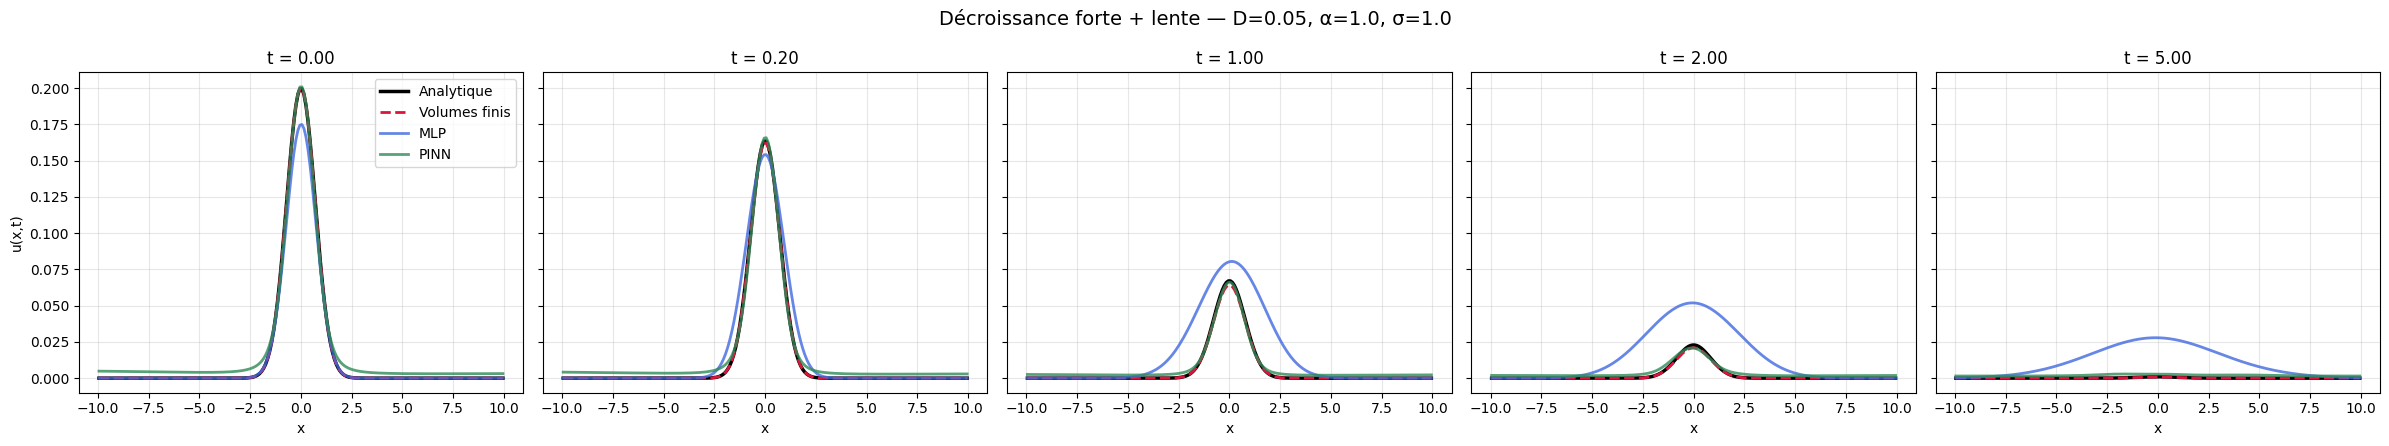

espace de temps 0.005000000000000001 espace de position 0.1


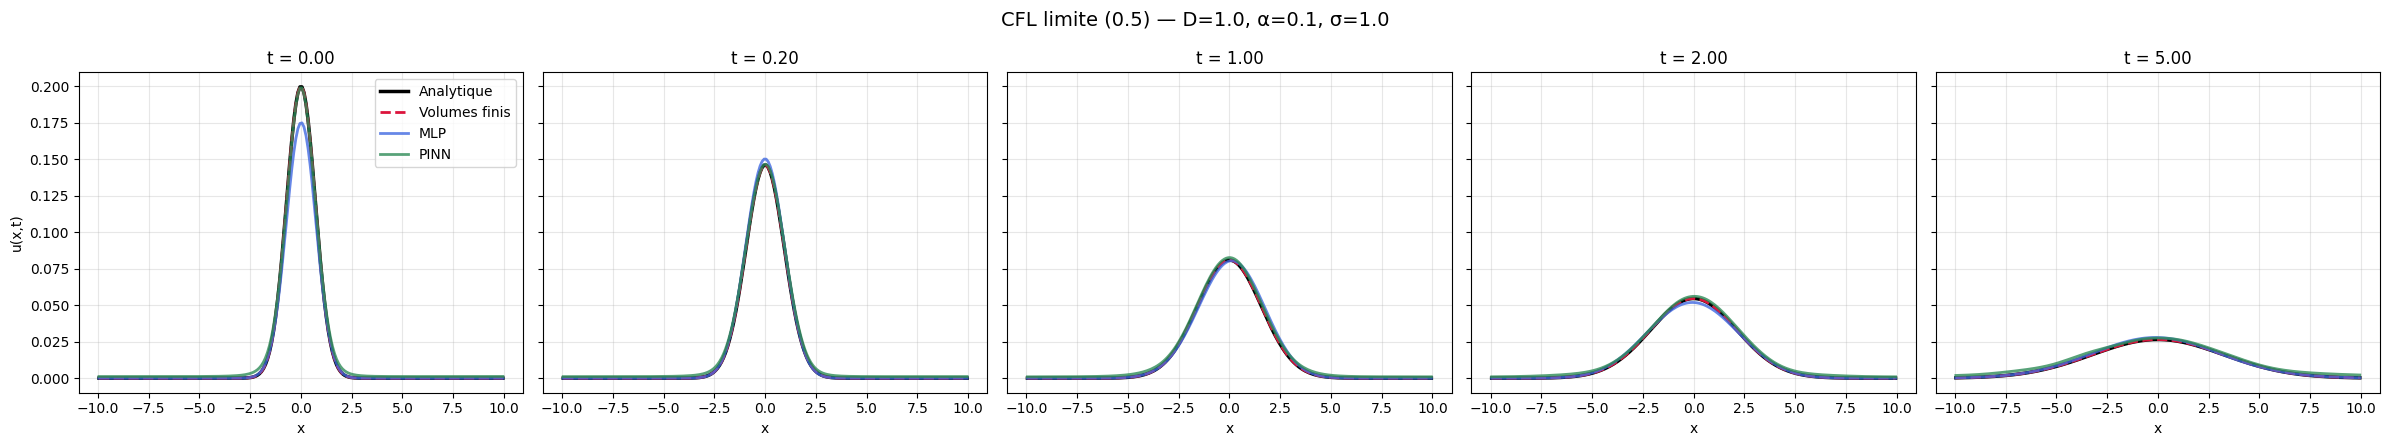

espace de temps 0.006000000000000001 espace de position 0.1


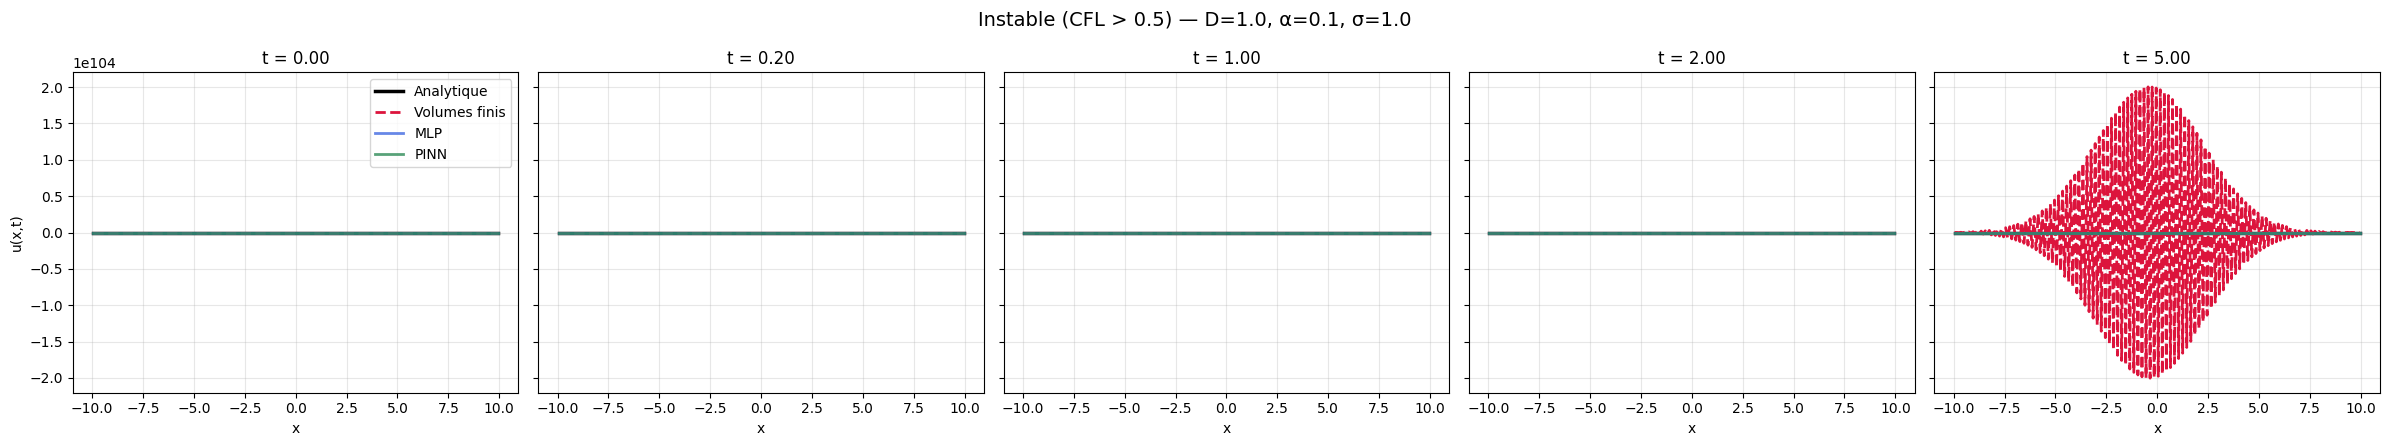

In [64]:
temps_a_tracer = [1e-4, 0.2, 1, 2, T]

for nom, p in scenarios.items():
    D_s, alpha_s, sigma_s, clf_s = p["D"], p["alpha"], p["sigma"], p["clf"]

    # Volumes finis + analytique pour ce scénario
    x_VF, t_VF, U_num = u_volume_finie(A=A, x0=x0, sigma=sigma_s, D=D_s,
                                        alpha=alpha_s, L=L, T=T, Nx=Nx, clf=clf_s)

    # PINN entraîné spécifiquement pour ce scénario
    pinn_s = train_pinn_scenario(D=D_s, alpha=alpha_s, sigma=sigma_s,
                              epochs=5000, lambda_pde=8.0,
                              N_ic=300, N_bc=300, N_r=1000)

    # MLP (entraîné une seule fois sur le régime de référence) évalué sur CE scénario,
    # pour bien montrer qu'il ne s'adapte pas au changement de D, alpha, sigma
    x_n = (x_VF - x_mean) / x_std

    fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(24, 4.5), sharey=True)

    for col, ti in enumerate(temps_a_tracer):
        ax = axes[col]
        idx = np.argmin(np.abs(t_VF - ti))

        # --- Analytique et Volumes Finis : propres à CE scénario ---
        u_exacte_ti = u_analytique(x_VF, t_VF[idx], A, x0, sigma_s, D_s, alpha_s)
        u_vf_ti = U_num[idx, :]

        # --- MLP : modèle fixe, évalué sur la grille de CE scénario ---
        t_n = (np.full_like(x_VF, t_VF[idx]) - t_mean) / t_std
        Xg = torch.tensor(np.column_stack([x_n, t_n]), dtype=torch.float32)
        model.eval()
        with torch.no_grad():
            u_log_pred = model(Xg).numpy().flatten() * u_std + u_mean
        u_mlp_ti = np.exp(u_log_pred) - eps

        # --- PINN : ré-entraîné pour CE scénario ---
        pinn_s.eval()
        with torch.no_grad():
            xt = torch.tensor(np.column_stack([x_VF, np.full_like(x_VF, t_VF[idx])]),
                               dtype=torch.float32)
            u_pinn_ti = pinn_s(xt).numpy().flatten()

        ax.plot(x_VF, u_exacte_ti, color='black', linewidth=2.5, label="Analytique")
        ax.plot(x_VF, u_vf_ti, color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
        ax.plot(x_VF, u_mlp_ti, color='royalblue', linewidth=2, alpha=0.8, label="MLP")
        ax.plot(x_VF, u_pinn_ti, color='seagreen', linewidth=2, alpha=0.8, label="PINN")

        ax.set_title(f"t = {ti:.2f}", fontsize=12)
        ax.set_xlabel('x'); ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('u(x,t)')
    axes[0].legend(fontsize=10)
    fig.suptitle(f"{nom} — D={D_s}, α={alpha_s}, σ={sigma_s}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'scenario_PINN_{nom[:15].replace(" ", "_")}.png', dpi=200, bbox_inches='tight')
    plt.show()